# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 5     |  |
| :-------------|:-------------|
| Farzat Darboli| 6535925 |
| Lukas Calixtro| 6528619 |
| Hidde Petiet | 6583695 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Farzat Darboli', 'Lukas Calixtro','Hidde Petiet']

## Opdracht 1: Planning.

| Planning Groep: 5     |Tijdstip / Tijdspanne  |
|---|---|
| Sensors kalibreren | 11:15 |
| Eerste iteratie test meting af| 12:45 |
| Test iteraties af | 14:45 |
| Ontwerp schetsen af | 12:45 |
| Iteraties en algorithme af| 16:00 |
| Inleveren en feedback| 17:45 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:45 |
| Pauze 2| 15:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit 

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [5]
<img src="kalibratie.jpeg" width="400">

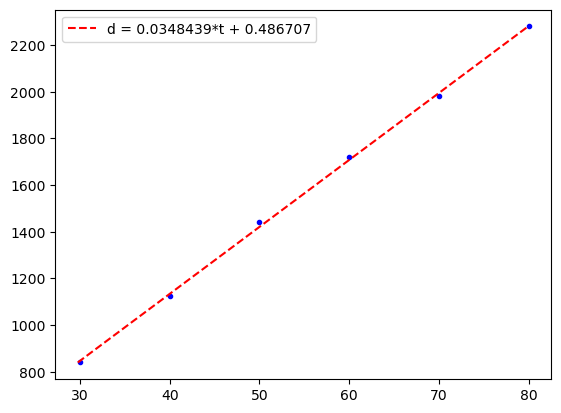

In [3]:
# verwerk hier jullie kalibratiemetingen

d = np.array([30,40,50,60,70,80])
t = np.array([840,1127,1440,1720,1980,2280])
def f(t, a, b):
    return a*t+b
popt, pcov = curve_fit(f,t,d)
a , b = popt[0],popt[1]
u_a , u_b = np.sqrt(pcov[0][0]), np.sqrt(pcov[1][1])

plt.plot(d,t,'b.')
plt.plot(f(t, a, b), t, 'r--', label=f'd = {a:.6g}*t + {b:.6g}')
plt.legend()
plt.show()



## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  44.8
1   0  30   0  20  43.3
2  40   0  30   0  43.5
3  30   0  20   0  42.6


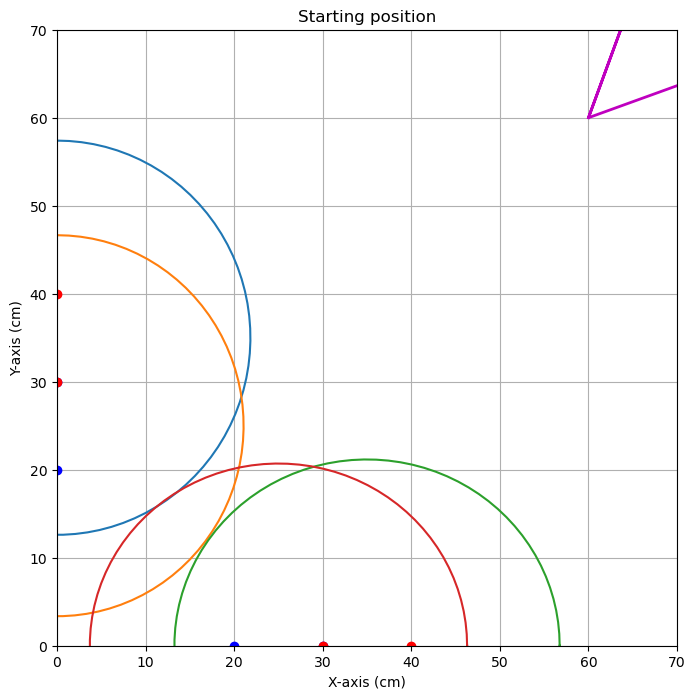


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=98.405


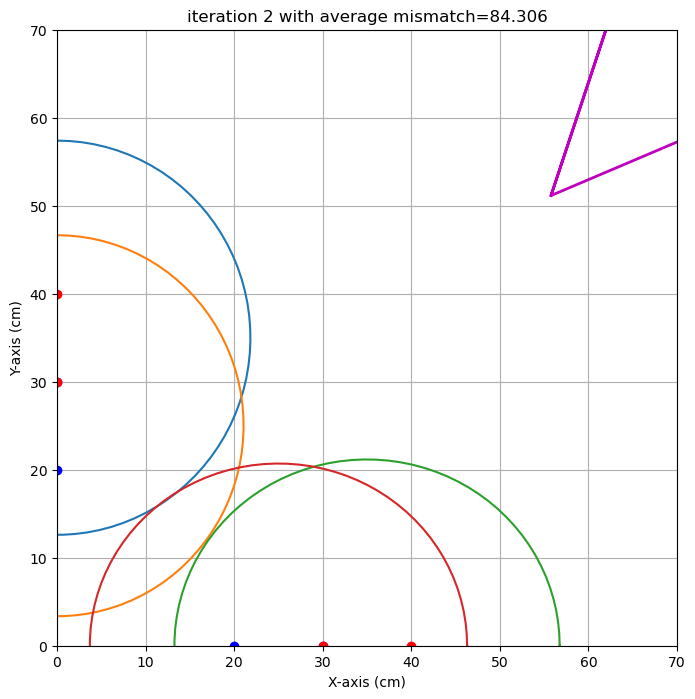

end iteration 2 with average mismatch=84.306


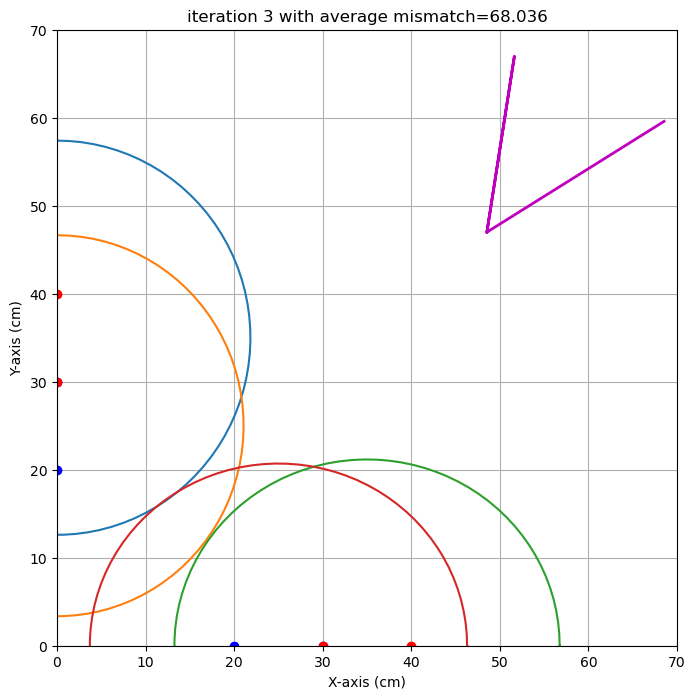

end iteration 3 with average mismatch=68.036


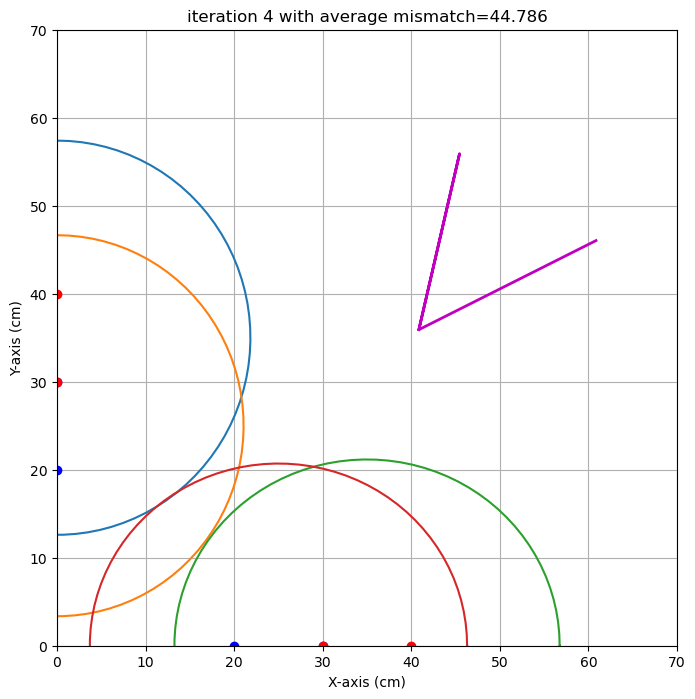

end iteration 4 with average mismatch=44.786


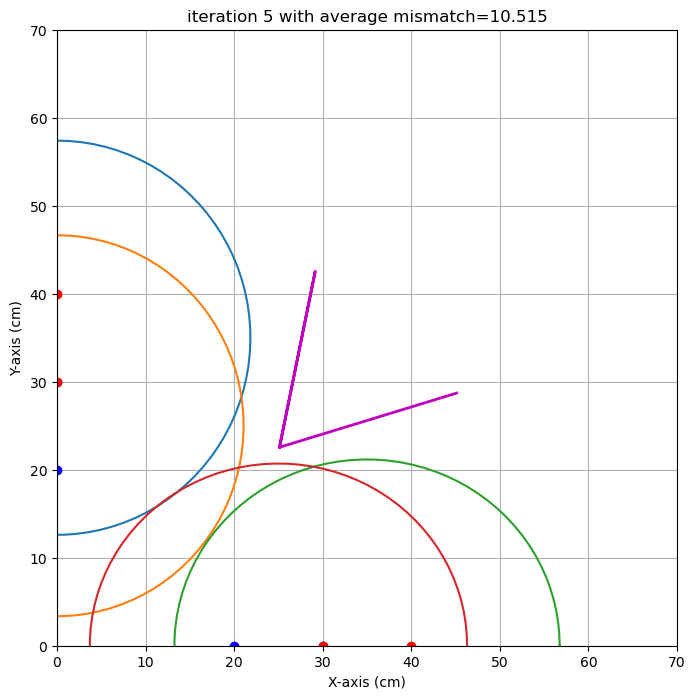

end iteration 5 with average mismatch=10.515


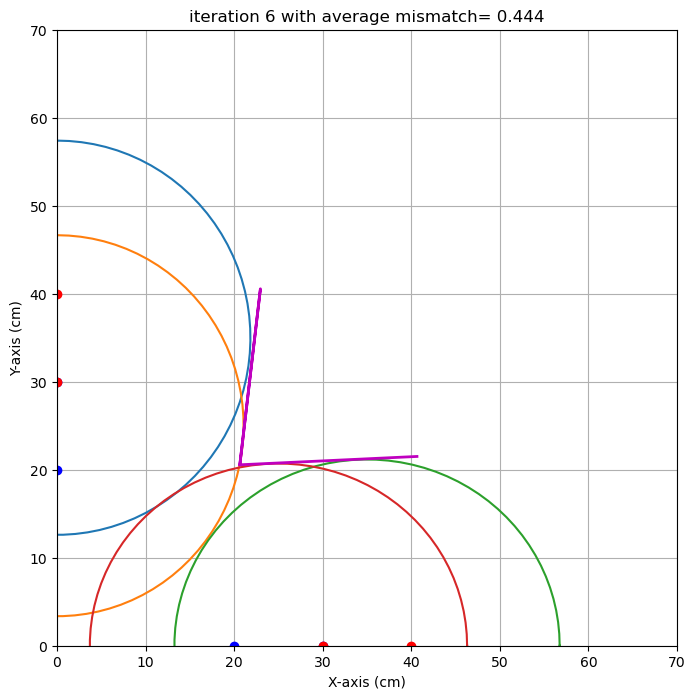

end iteration 6 with average mismatch= 0.444
end iteration 7 with average mismatch= 0.425


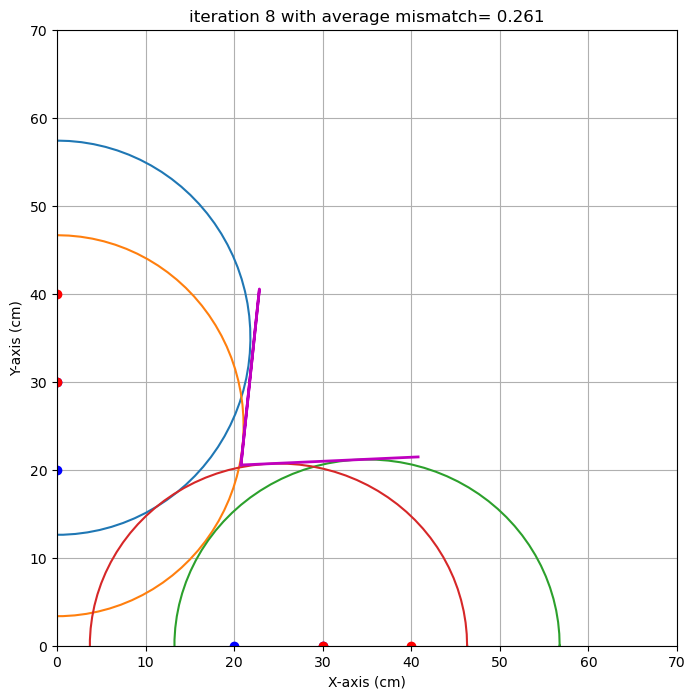

end iteration 8 with average mismatch= 0.261
end iteration 9 with average mismatch= 0.261
end iteration 10 with average mismatch= 0.260
end iteration 11 with average mismatch= 0.260
end iteration 12 with average mismatch= 0.260
end iteration 13 with average mismatch= 0.260
end iteration 14 with average mismatch= 0.260
end iteration 15 with average mismatch= 0.260
end iteration 16 with average mismatch= 0.260
end iteration 17 with average mismatch= 0.260
end iteration 18 with average mismatch= 0.260
end iteration 19 with average mismatch= 0.260
end iteration 20 with average mismatch= 0.260


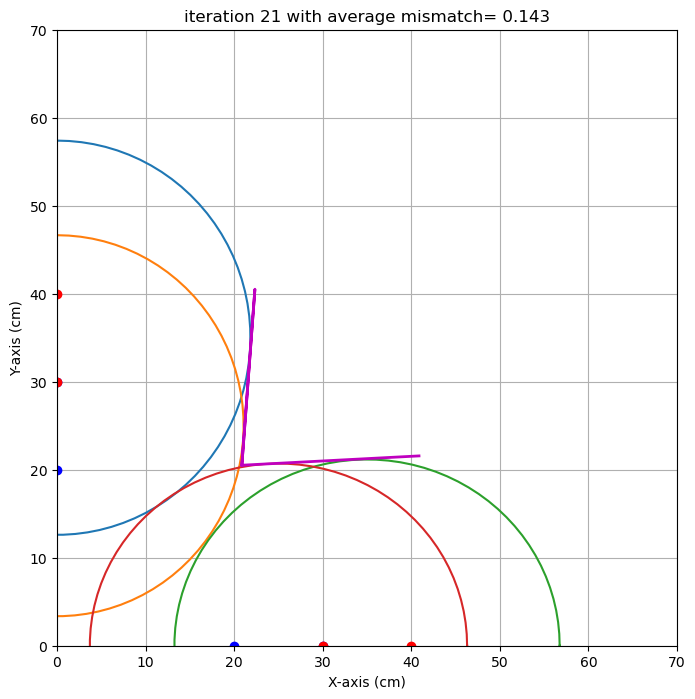

end iteration 21 with average mismatch= 0.143
end iteration 22 with average mismatch= 0.132
end iteration 23 with average mismatch= 0.126
end iteration 24 with average mismatch= 0.123
end iteration 25 with average mismatch= 0.123
end iteration 26 with average mismatch= 0.122
end iteration 27 with average mismatch= 0.122
end iteration 28 with average mismatch= 0.122
end iteration 29 with average mismatch= 0.122
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.122
###############################################################################
end of iteration  30
Best alpha=   3.03 with uncertainty=   0.00
Best beta =   4.21 with uncertainty=   0.00
Best x0   =  20.85 with uncertainty=   0.00
Best y0   =  20.50 with uncertainty=   0.00
###############################################################################
no uncertainty found, pl

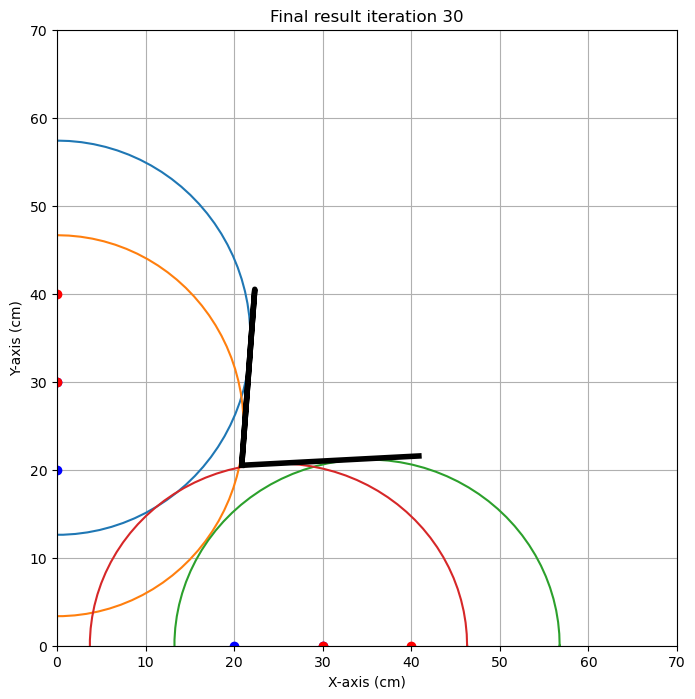

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.8],
    [0,30,0,20,43.3],
    #[0,10,0,20,3.0],
    [40,0,30,0,43.5],
    [30,0,20,0,42.6],
    #[10,0,20,0,6.0],
    #[10,0,0,10,7.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.9 cm met een standaardafwijking van 0.0 cm 
y0: 20.5 cm met een standaardafwijking van 0.0 cm 
alpha: 3.0 graden met een standaardafwijking van 0.0 graad 
beta: 4.2 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Farzat Darboli]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="farzat.jpeg" width="400">

#### algoritme [Lukas Calixtro]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="lukas.jpeg" width="400">

#### algoritme [Hidde Petiet]
Voeg een foto in van het algoritme van het derde groepslid
<img src="hidde2.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':28,  #zelf aanvullen,
           'y0':35.5,#zelf aanvullen,
           'alpha' : 2,#zelf aanvullen,
           'beta' :11.5, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Hidde Petiet' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[    
    [0,70,0,60,69.8], 
    [0,60,0,50,65.1],
    [0,50,0,40,61.2],
    #[0,40,0,30,ongeldig],
    #[0,0,10,0,ongeldig],
    #[10,0,20,0,ongeldig],
    #[20,0,30,0,ongeldig],
    [30,0,40,0,71.9],
    [40,0,50,0,74.1],
    [50,0,60,0,76.8],
    ]),
       'Lukas Calixtro' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[     
    [0,60,0,40,65.9], 
    [0,50,0,40,59.9],
    [0,60,0,50,64.3],
    [40,0,30,0,76.6],
    [40,0,20,0,72.6],
    #[30,0,20,0,ongeldig]
    
    ]),
       'Farzat Darboli' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

## Opdracht 7: Evaluatie.

Farzat Darboli
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


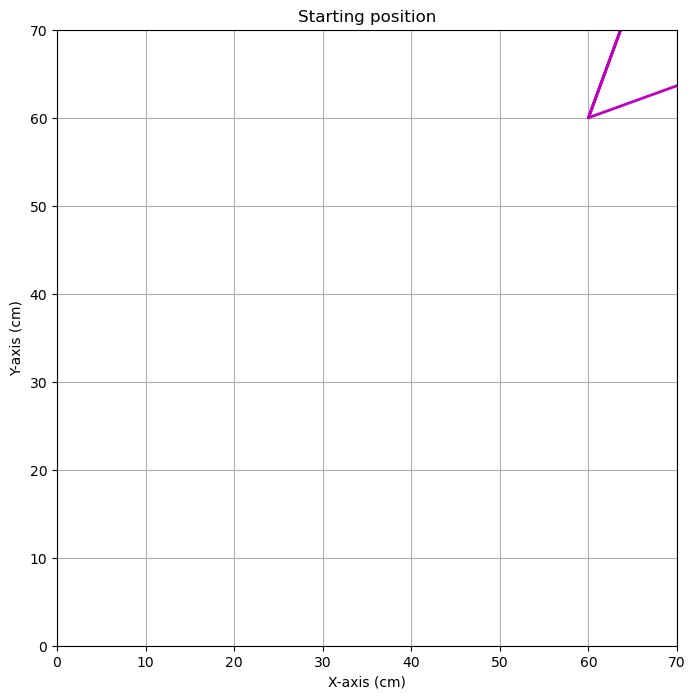


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan


c:\Users\darbo\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\darbo\miniconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with average mismatch=   nan
end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismatch=   nan
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration

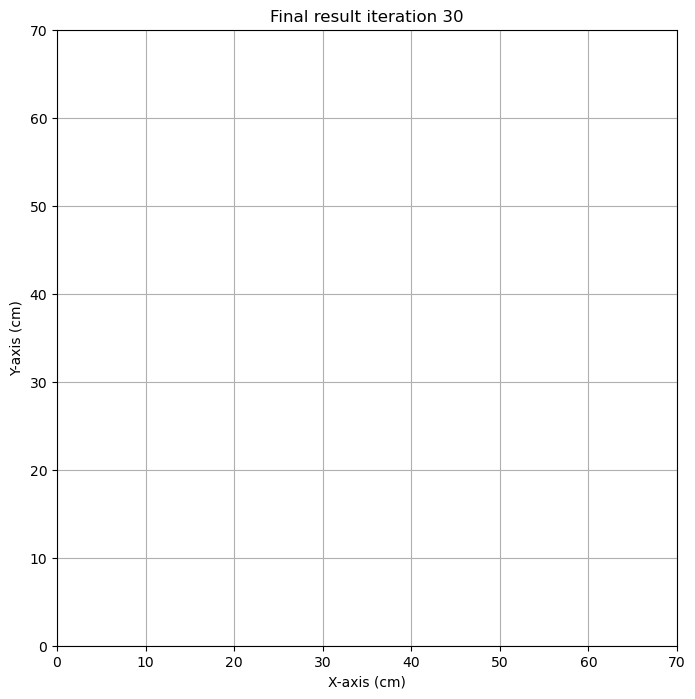

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}
Lukas Calixtro
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  60   0  40  65.9
1   0  50   0  40  59.9
2   0  60   0  50  64.3
3  40   0  30   0  76.6
4  40   0  20   0  72.6


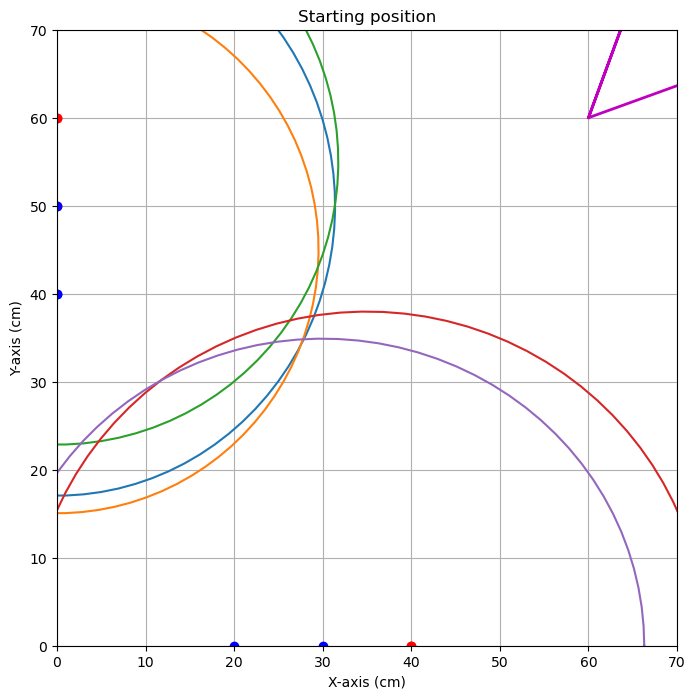


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.246


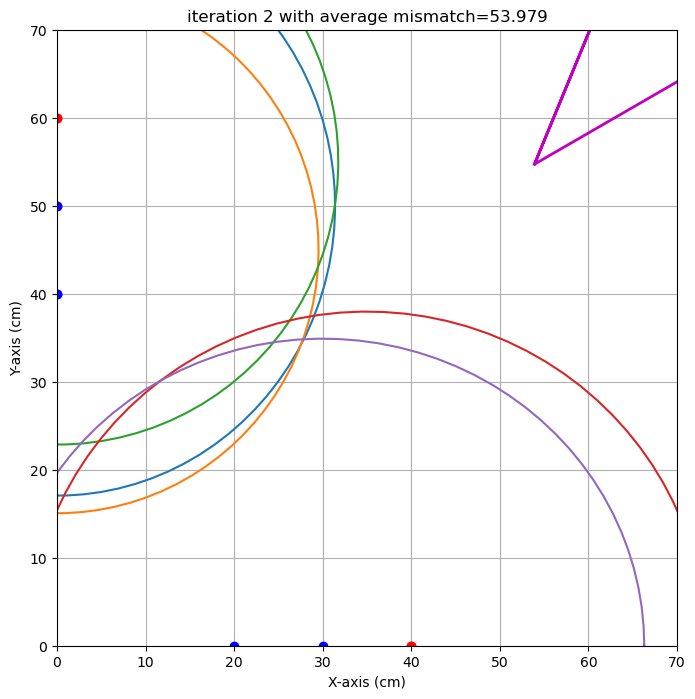

end iteration 2 with average mismatch=53.979


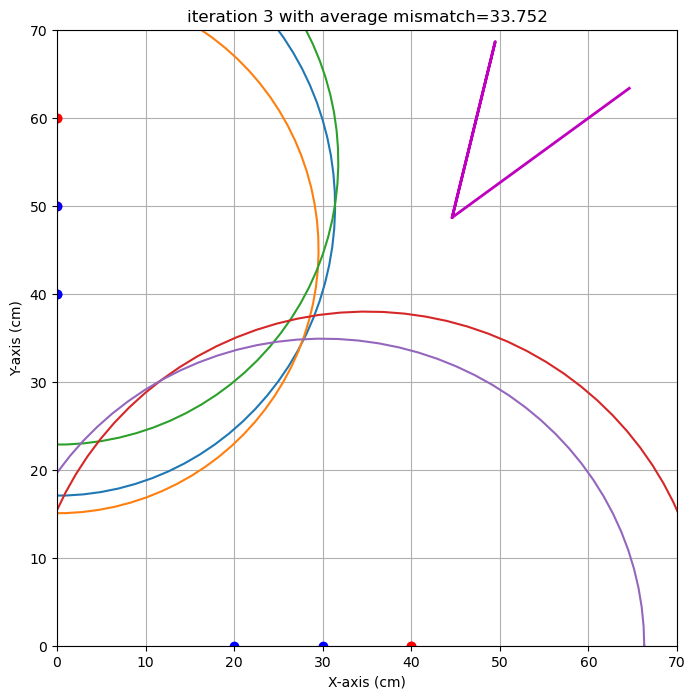

end iteration 3 with average mismatch=33.752


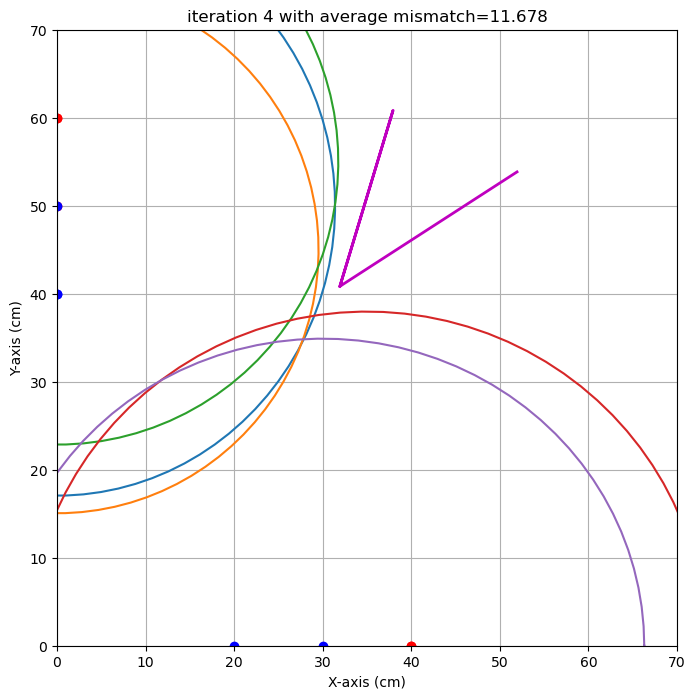

end iteration 4 with average mismatch=11.678


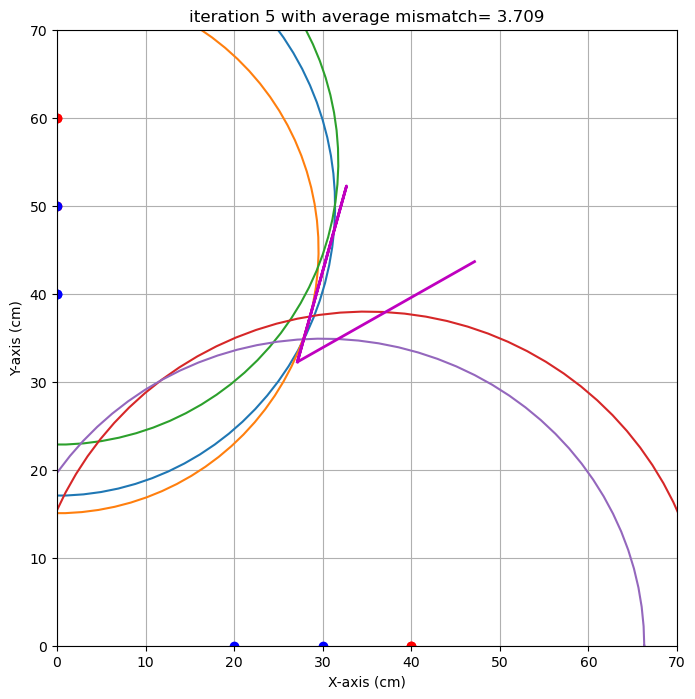

end iteration 5 with average mismatch= 3.709


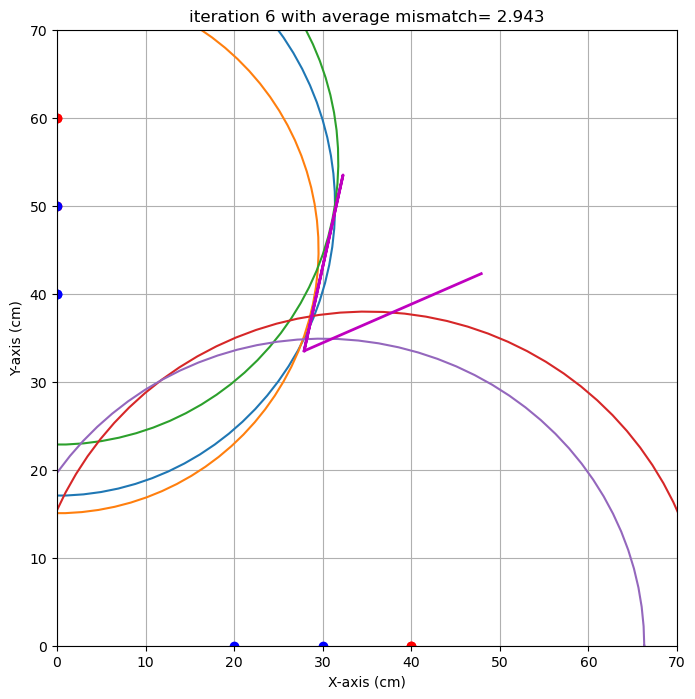

end iteration 6 with average mismatch= 2.943


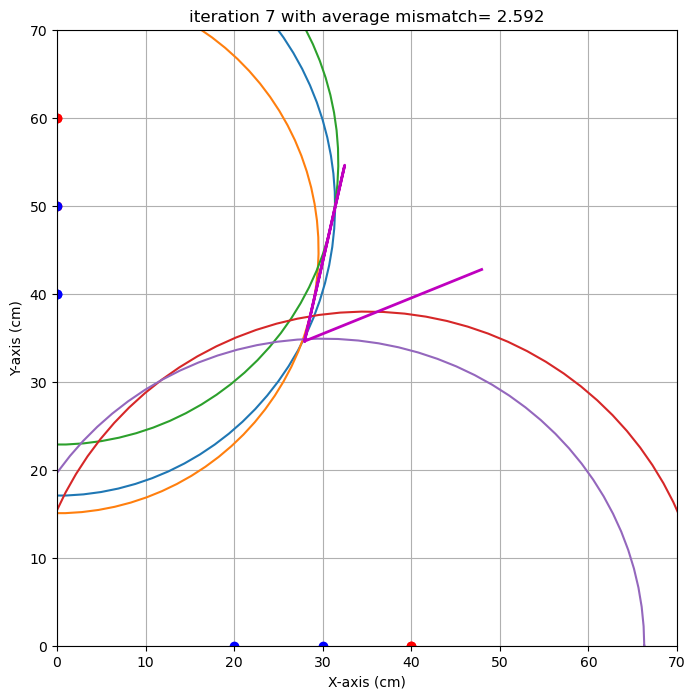

end iteration 7 with average mismatch= 2.592
end iteration 8 with average mismatch= 2.586
end iteration 9 with average mismatch= 2.586
end iteration 10 with average mismatch= 2.543
end iteration 11 with average mismatch= 2.431


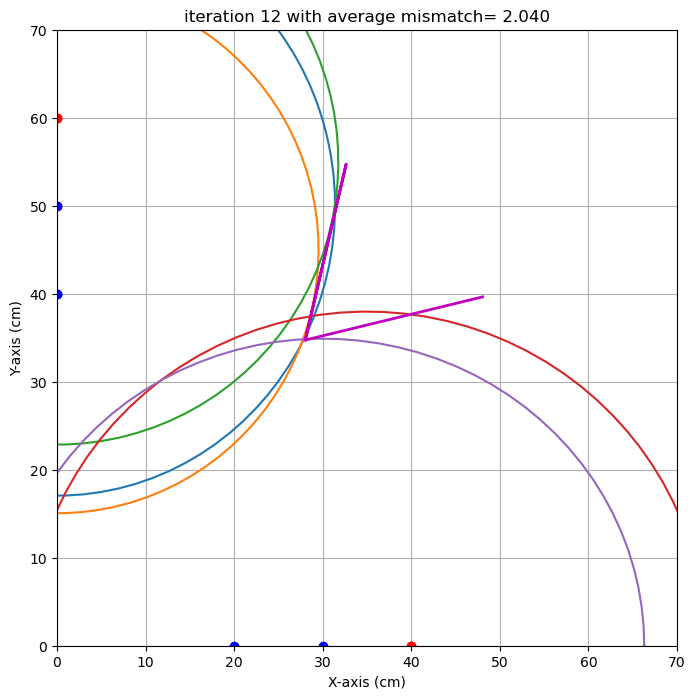

end iteration 12 with average mismatch= 2.040


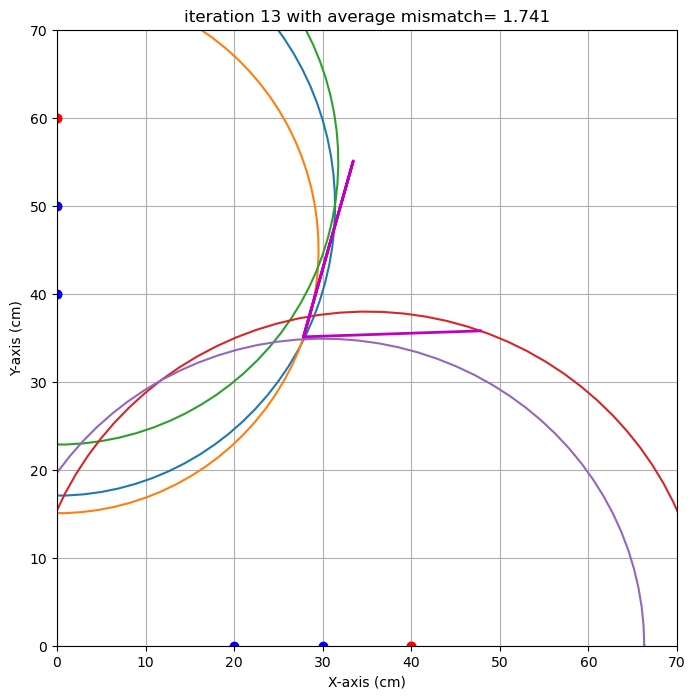

end iteration 13 with average mismatch= 1.741


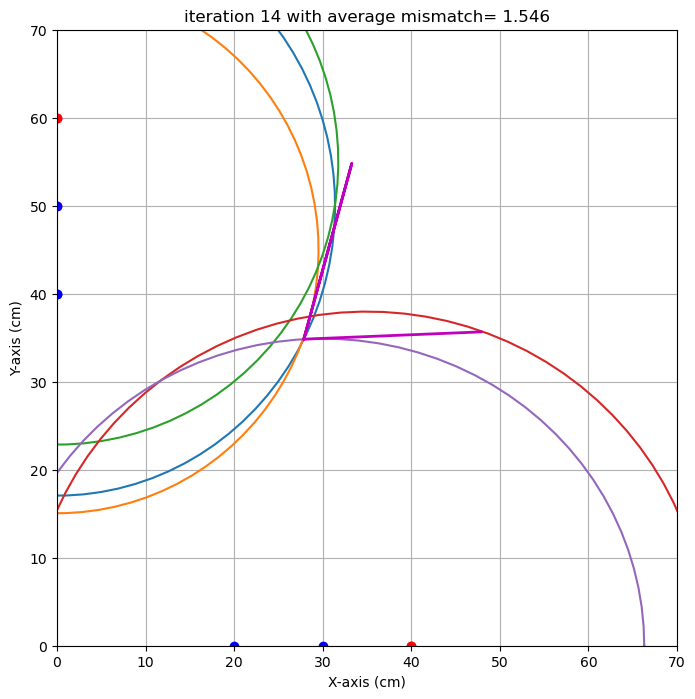

end iteration 14 with average mismatch= 1.546
end iteration 15 with average mismatch= 1.472
end iteration 16 with average mismatch= 1.470
end iteration 17 with average mismatch= 1.450
end iteration 18 with average mismatch= 1.450
end iteration 19 with average mismatch= 1.450
end iteration 20 with average mismatch= 1.450
end iteration 21 with average mismatch= 1.450
end iteration 22 with average mismatch= 1.450
end iteration 23 with average mismatch= 1.450
end iteration 24 with average mismatch= 1.450
end iteration 25 with average mismatch= 1.450
end iteration 26 with average mismatch= 1.450
end iteration 27 with average mismatch= 1.450
end iteration 28 with average mismatch= 1.450
end iteration 29 with average mismatch= 1.450
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.450
###############################################################################
end of iteration  30
Best alp

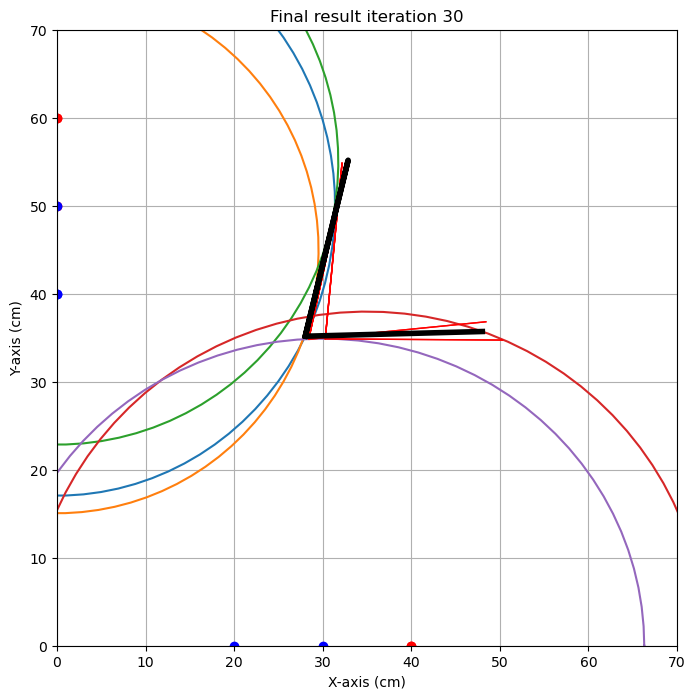

{'alpha': np.float64(1.5343371067007734), 'alpha_eps': np.float64(4.154795784751909), 'beta': np.float64(13.617785963623719), 'beta_eps': np.float64(8.191323968828687), 'x0': np.float64(28.021465223826425), 'x0_eps': np.float64(2.2600441604928783), 'y0': np.float64(35.169820841282984), 'y0_eps': np.float64(0.3512701815703849)}
Hidde Petiet
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  70   0  60  69.8
1   0  60   0  50  65.1
2   0  50   0  40  61.2
3  30   0  40   0  71.9
4  40   0  50   0  74.1
5  50   0  60   0  76.8


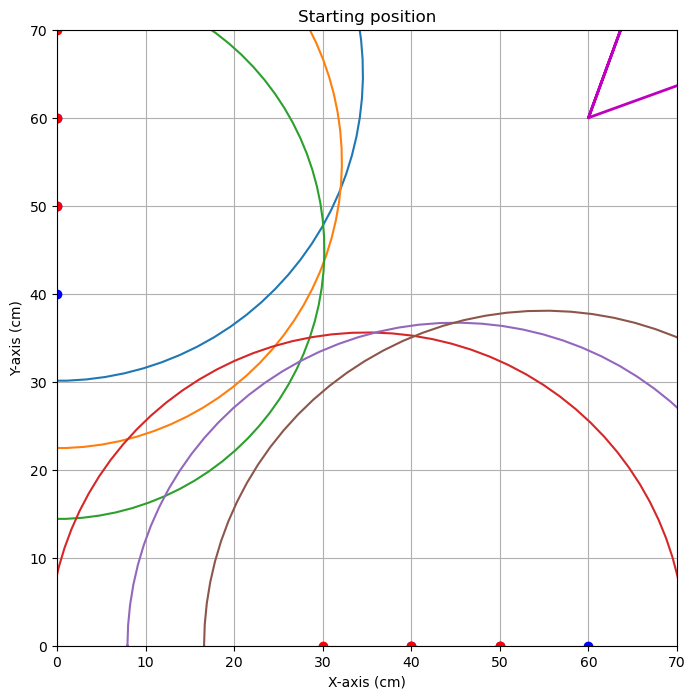


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.398


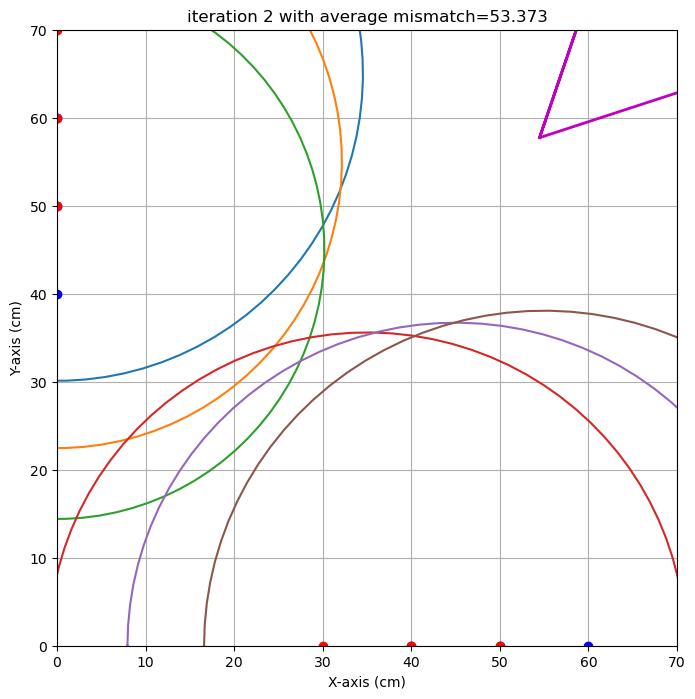

end iteration 2 with average mismatch=53.373


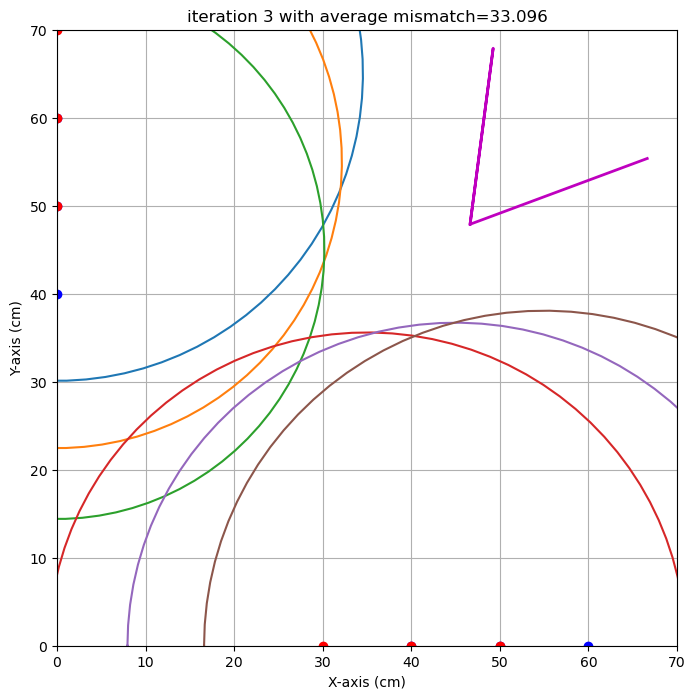

end iteration 3 with average mismatch=33.096


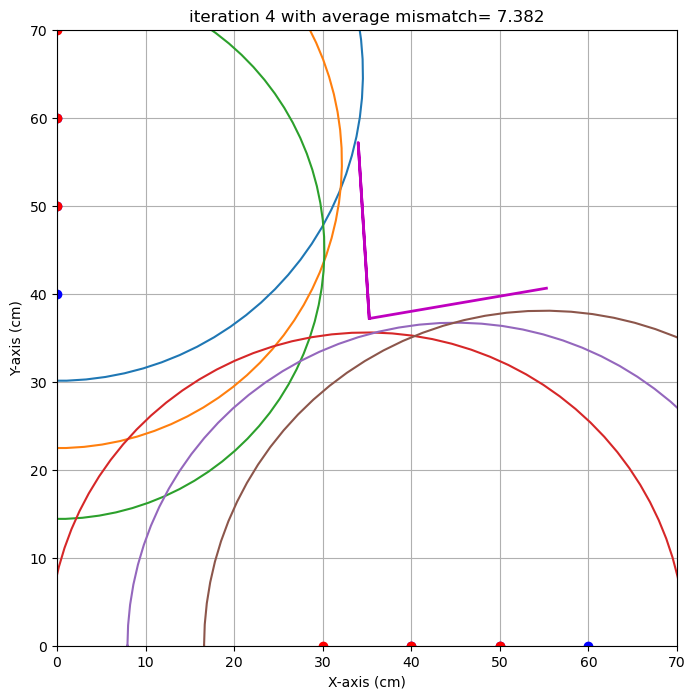

end iteration 4 with average mismatch= 7.382


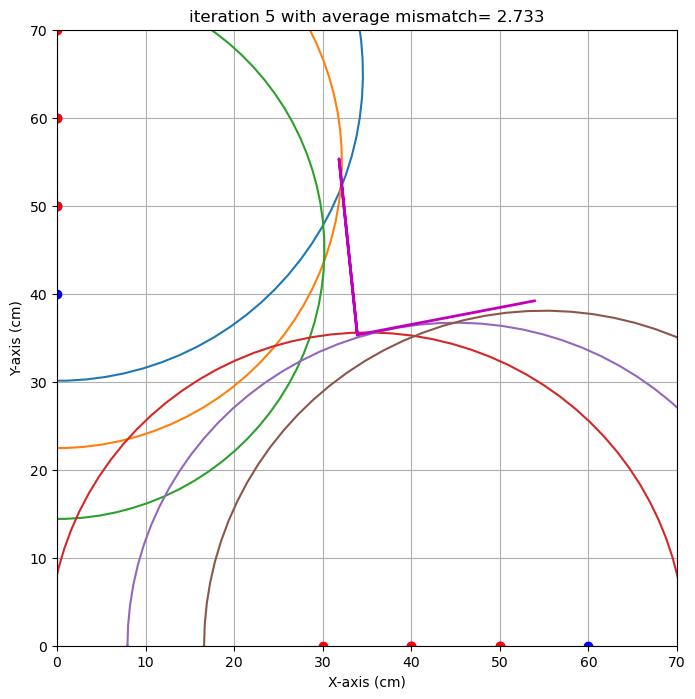

end iteration 5 with average mismatch= 2.733


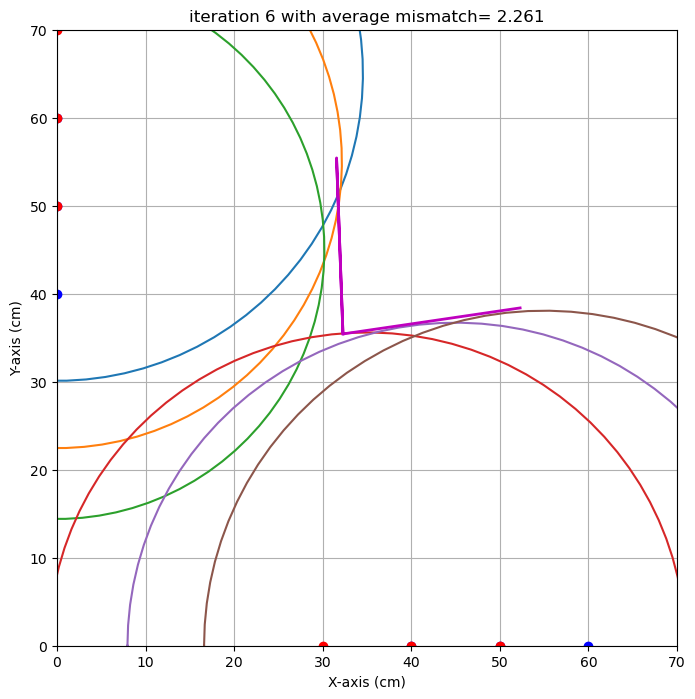

end iteration 6 with average mismatch= 2.261
end iteration 7 with average mismatch= 2.167
end iteration 8 with average mismatch= 2.034


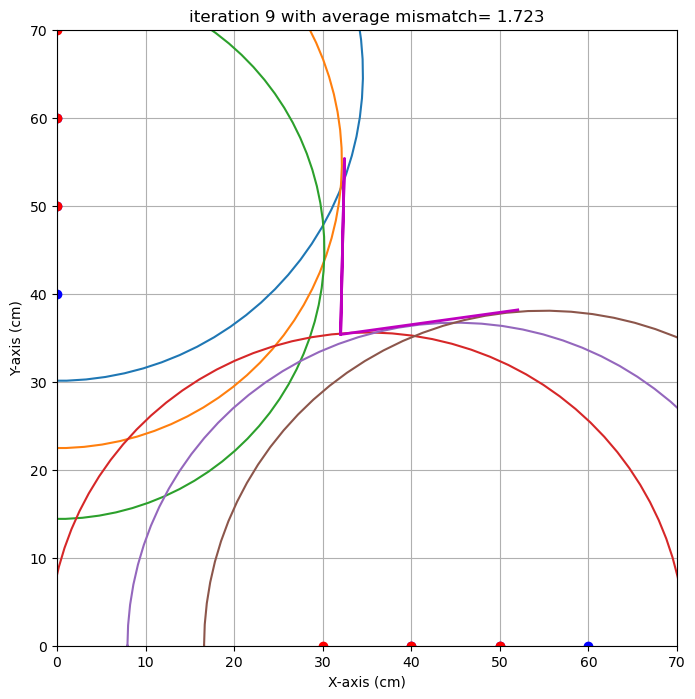

end iteration 9 with average mismatch= 1.723


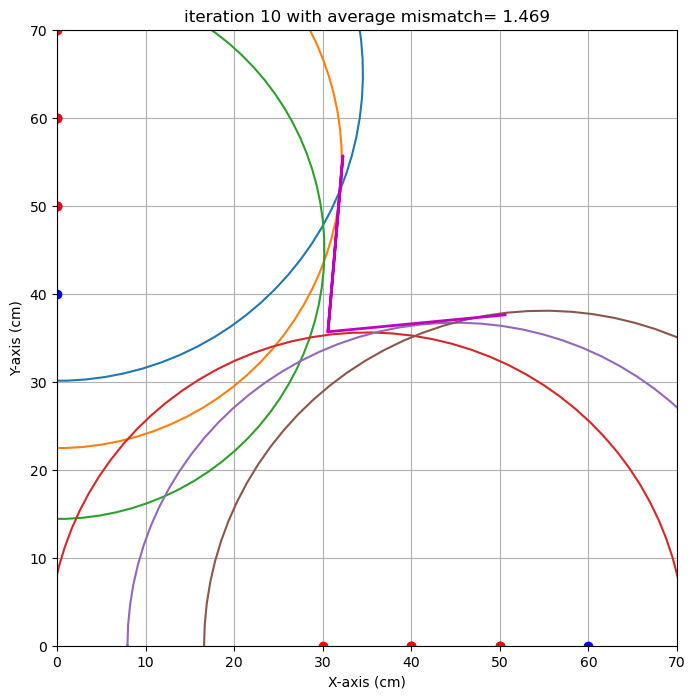

end iteration 10 with average mismatch= 1.469


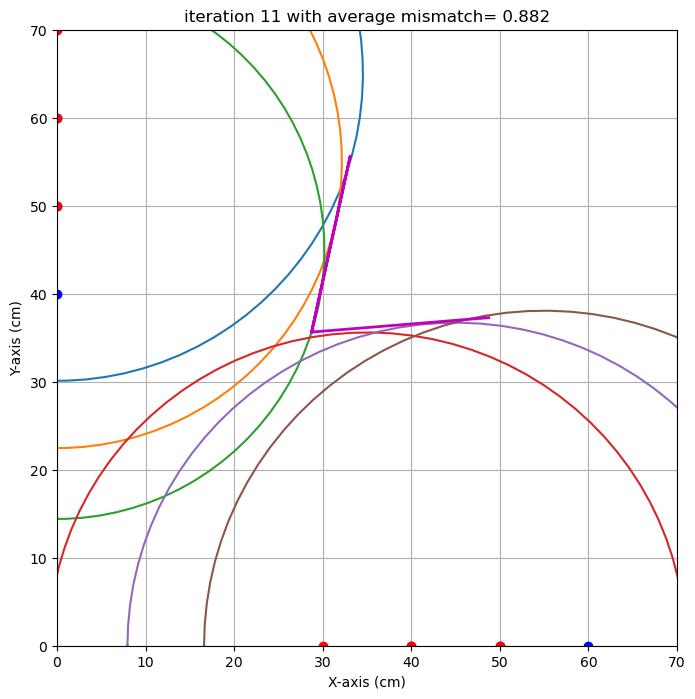

end iteration 11 with average mismatch= 0.882


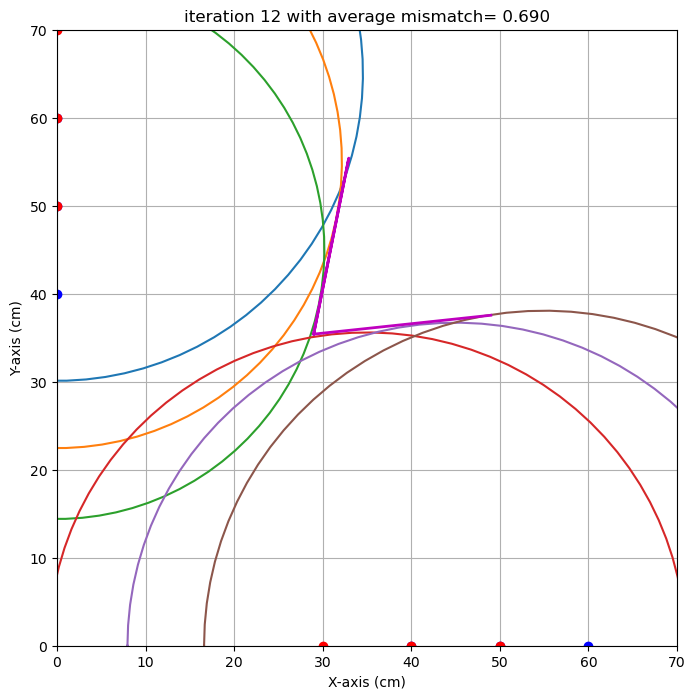

end iteration 12 with average mismatch= 0.690
end iteration 13 with average mismatch= 0.663
end iteration 14 with average mismatch= 0.663
end iteration 15 with average mismatch= 0.663
end iteration 16 with average mismatch= 0.663
end iteration 17 with average mismatch= 0.663
end iteration 18 with average mismatch= 0.663
end iteration 19 with average mismatch= 0.663
end iteration 20 with average mismatch= 0.663
end iteration 21 with average mismatch= 0.663
end iteration 22 with average mismatch= 0.663
end iteration 23 with average mismatch= 0.663
end iteration 24 with average mismatch= 0.663
end iteration 25 with average mismatch= 0.663
end iteration 26 with average mismatch= 0.663
end iteration 27 with average mismatch= 0.663
end iteration 28 with average mismatch= 0.663
end iteration 29 with average mismatch= 0.663
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.663
#################

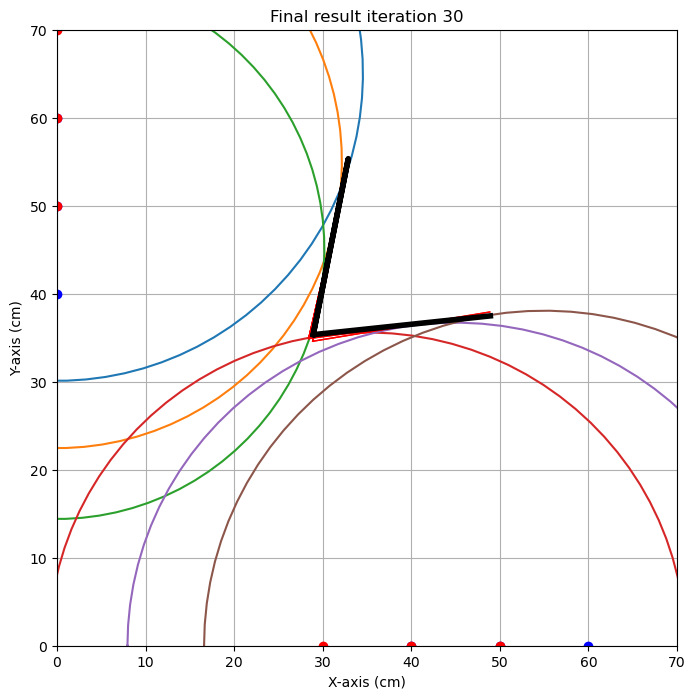

{'alpha': np.float64(6.08846540789666), 'alpha_eps': np.float64(3.3527198621078504), 'beta': np.float64(11.206666223444605), 'beta_eps': np.float64(1.7381534415244104), 'x0': np.float64(28.92174782780307), 'x0_eps': np.float64(0.5137865736555689), 'y0': np.float64(35.34768542077778), 'y0_eps': np.float64(0.7509725984197502)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Farzat Darboli 
x0 target is : 28.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 35.5. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 2.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : 11.5. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 

Lukas Calixtro 
x0 target is : 28.0. Gevonden waarde: 28.0 cm met een standaardafwijking van 2.3 cm 
y0 target is : 35.5. Gevonden waarde: 35.2 cm met een standaardafwijking van 0.4 cm 
alpha target is : 2.0. Gevonden waarde: 1.5 graden met een standaardafwijking van 4.2 graad 
beta target is : 11.5. Gevonden waarde: 13.6 graden met een standaardafwijking van 8.2 graad 

Hidde Petiet 
x0 target is : 28.0. Gevonden waarde: 28.9 cm met een standaardafwijking van 0.5 cm 
y0 target is : 35.5. Gevonden waarde: 35.3 cm met een standaardafwijking van 0.8 cm 
alpha target is : 2.0. Gevonden waarde: 6.1 graden met een standaardafw

## Opdracht 8: Iteratie1+.14:00.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](hidde4.jpeg)
Figuur 2 (iteratie 3): ![Alt](hidde5.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  60   0  50  47.0
1   0  50   0  40  50.2
2   0  40   0  30  54.1
3  30   0  40   0  76.7
4  40   0  50   0  78.3
5  50   0  60   0  81.1


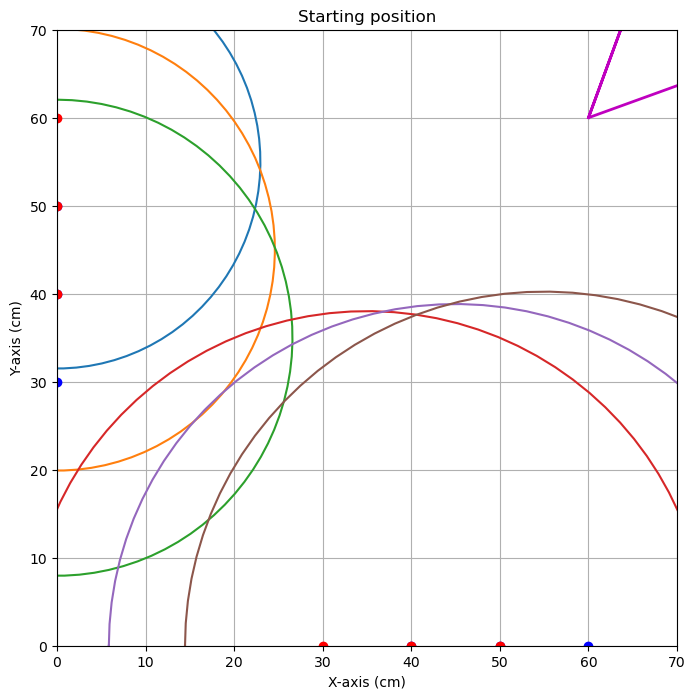


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=66.933


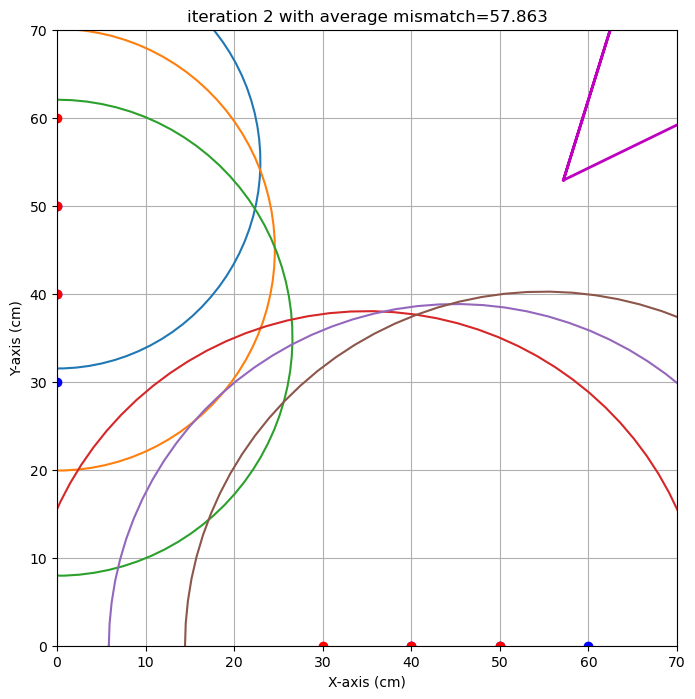

end iteration 2 with average mismatch=57.863


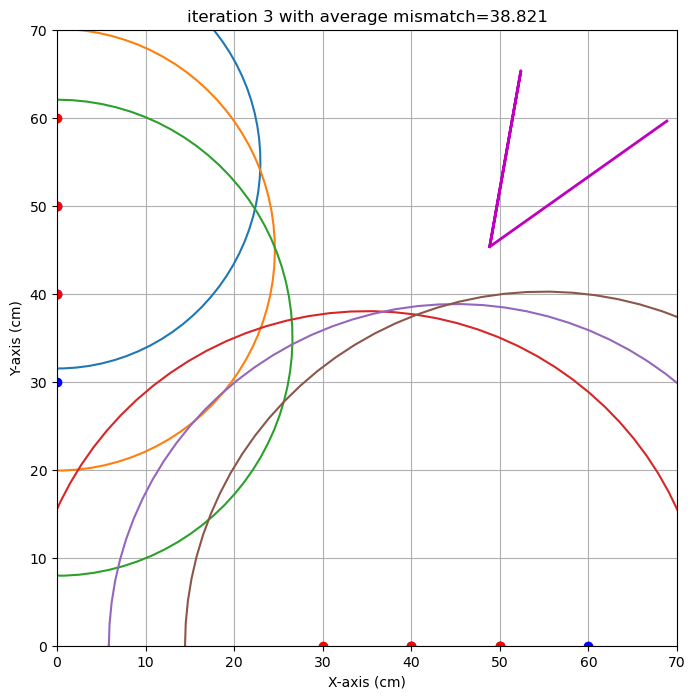

end iteration 3 with average mismatch=38.821


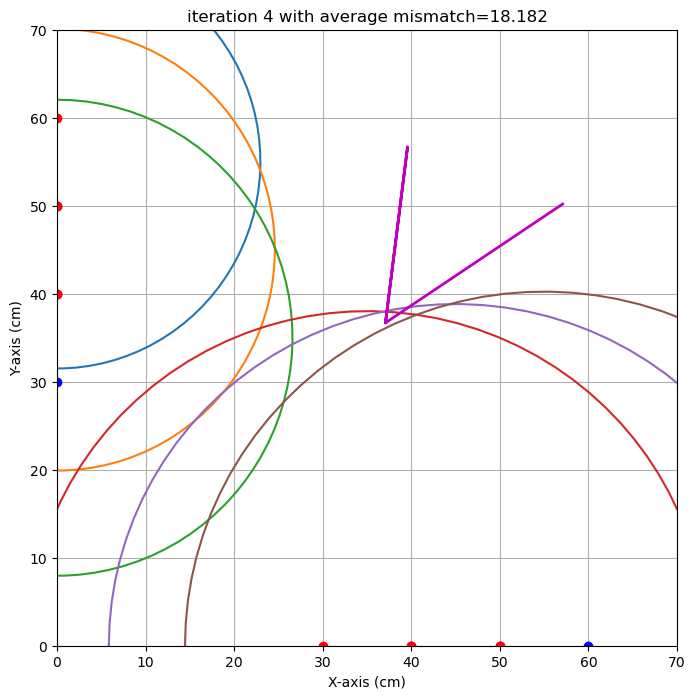

end iteration 4 with average mismatch=18.182


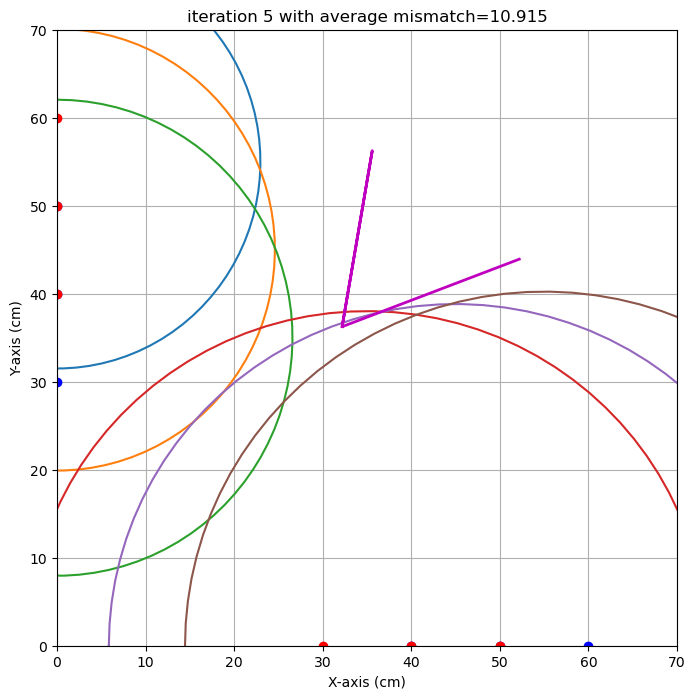

end iteration 5 with average mismatch=10.915


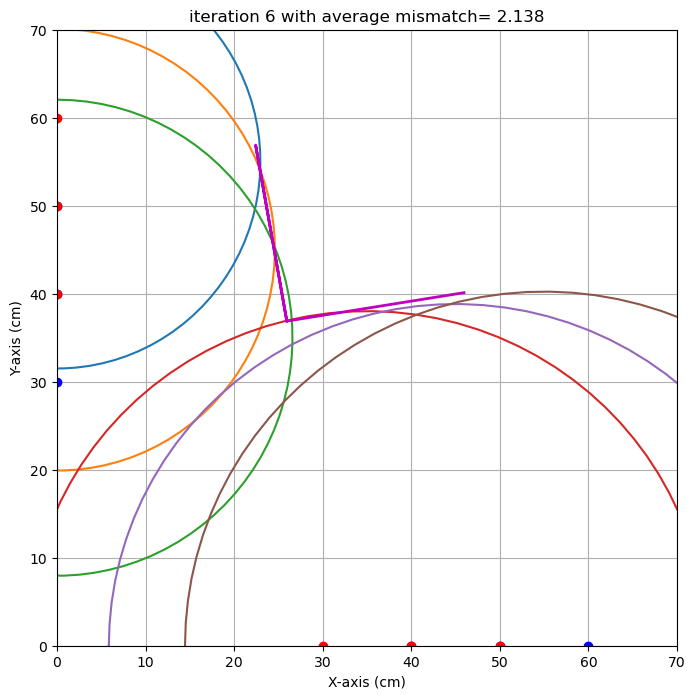

end iteration 6 with average mismatch= 2.138


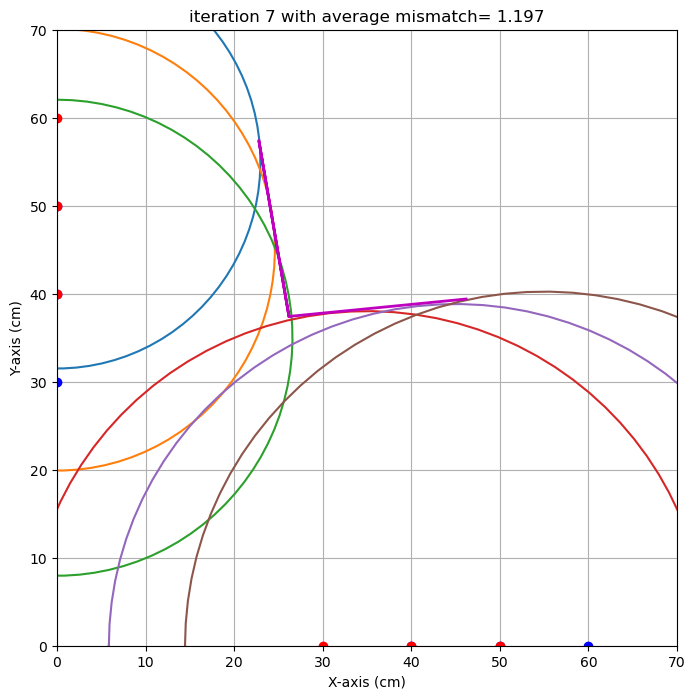

end iteration 7 with average mismatch= 1.197
end iteration 8 with average mismatch= 1.088
end iteration 9 with average mismatch= 0.992


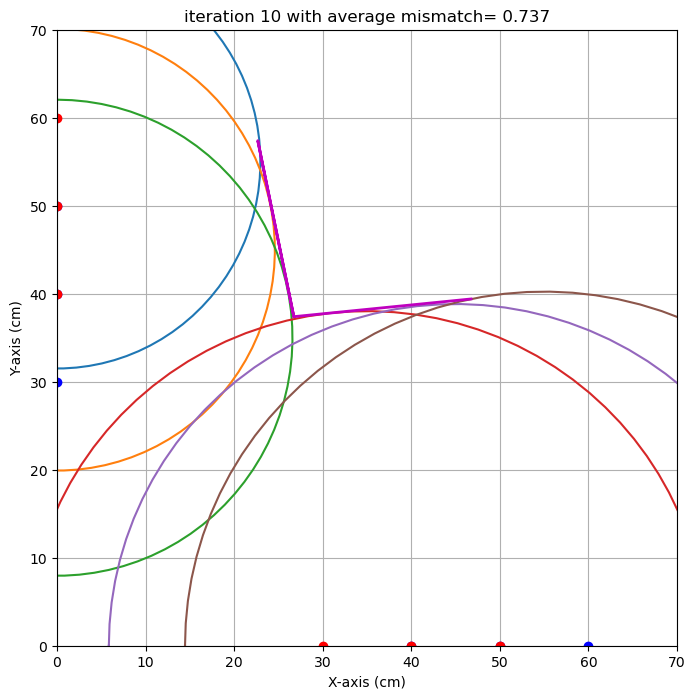

end iteration 10 with average mismatch= 0.737
end iteration 11 with average mismatch= 0.729
end iteration 12 with average mismatch= 0.729
end iteration 13 with average mismatch= 0.729
end iteration 14 with average mismatch= 0.729
end iteration 15 with average mismatch= 0.729
end iteration 16 with average mismatch= 0.729
end iteration 17 with average mismatch= 0.729
end iteration 18 with average mismatch= 0.729
end iteration 19 with average mismatch= 0.729
end iteration 20 with average mismatch= 0.729
end iteration 21 with average mismatch= 0.729
end iteration 22 with average mismatch= 0.729
end iteration 23 with average mismatch= 0.729
end iteration 24 with average mismatch= 0.729
end iteration 25 with average mismatch= 0.729
end iteration 26 with average mismatch= 0.729
end iteration 27 with average mismatch= 0.729
end iteration 28 with average mismatch= 0.729
end iteration 29 with average mismatch= 0.729
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

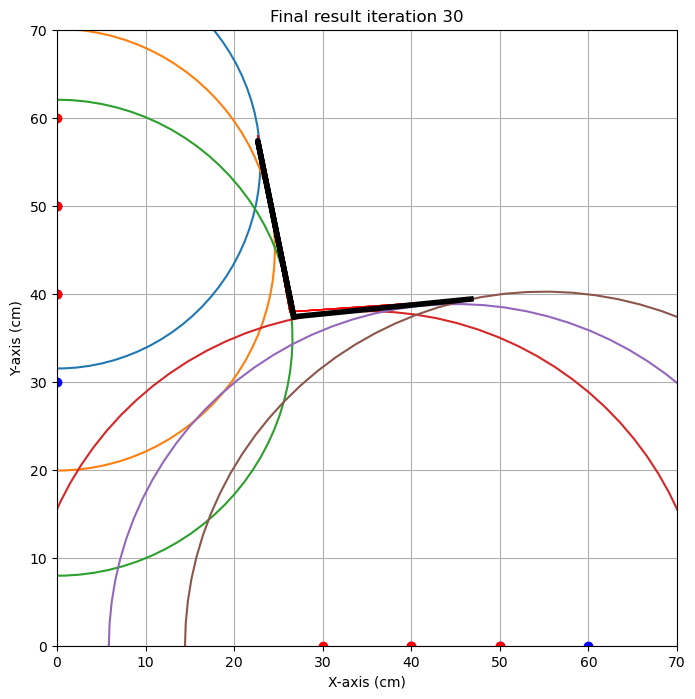

{'alpha': np.float64(5.740920877538784), 'alpha_eps': np.float64(1.7726743754273917), 'beta': np.float64(-11.505604897732965), 'beta_eps': np.float64(1.1799190106844364), 'x0': np.float64(26.730540769169654), 'x0_eps': np.float64(0.4260474336593454), 'y0': np.float64(37.38325342540936), 'y0_eps': np.float64(0.559363285468983)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  94.6
1  30   0  50   0  91.6
2   0  69   0  49  67.2
3   0  64   0  44  65.7


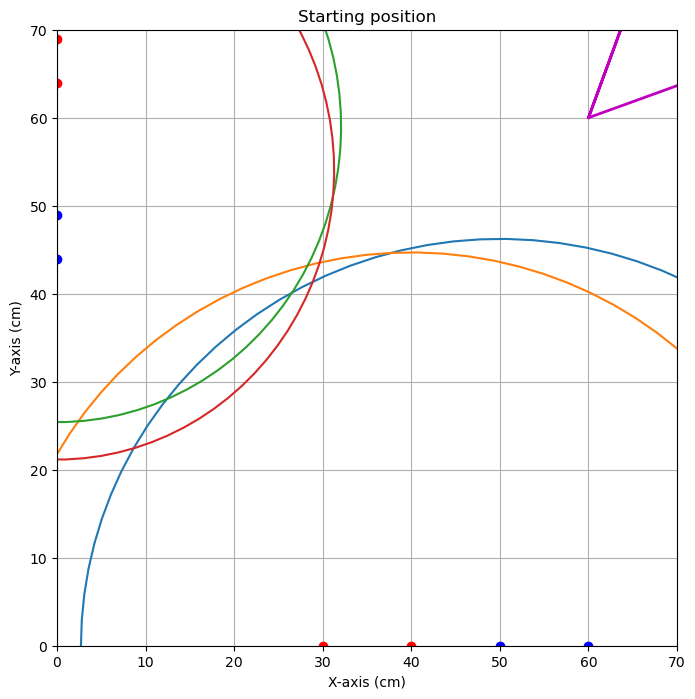


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.577


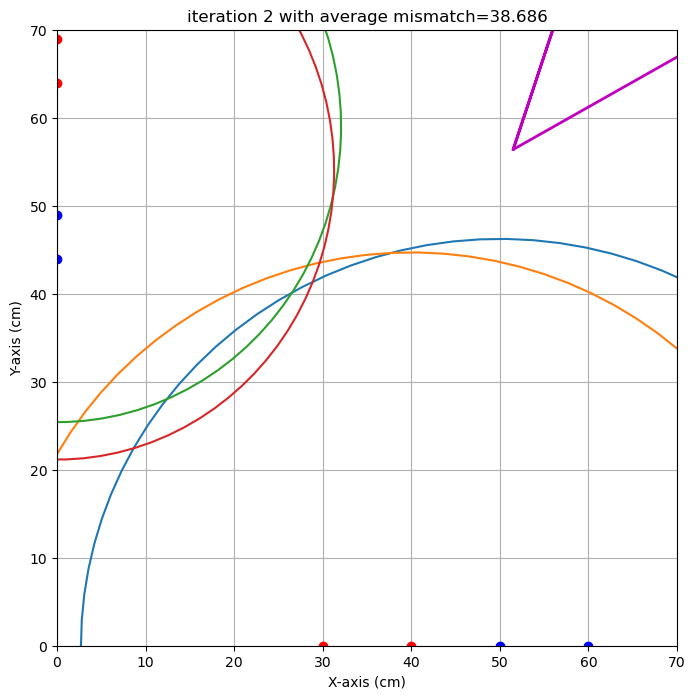

end iteration 2 with average mismatch=38.686


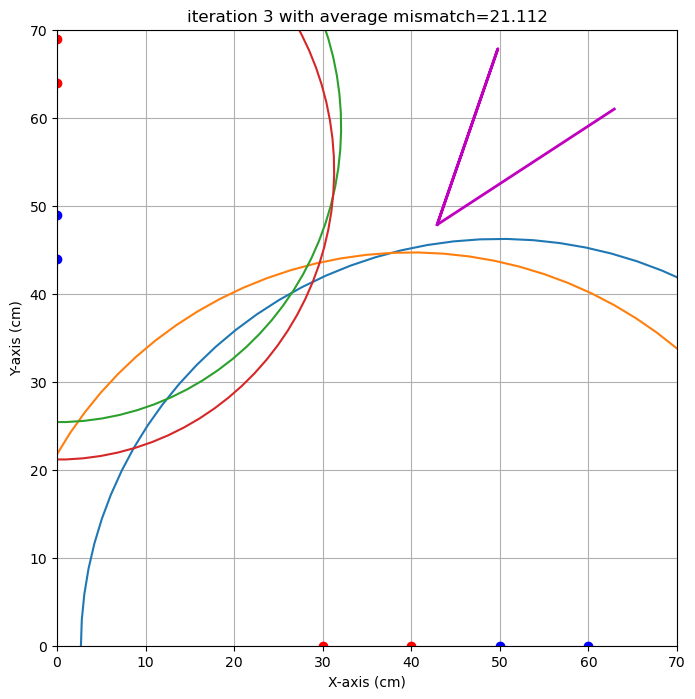

end iteration 3 with average mismatch=21.112


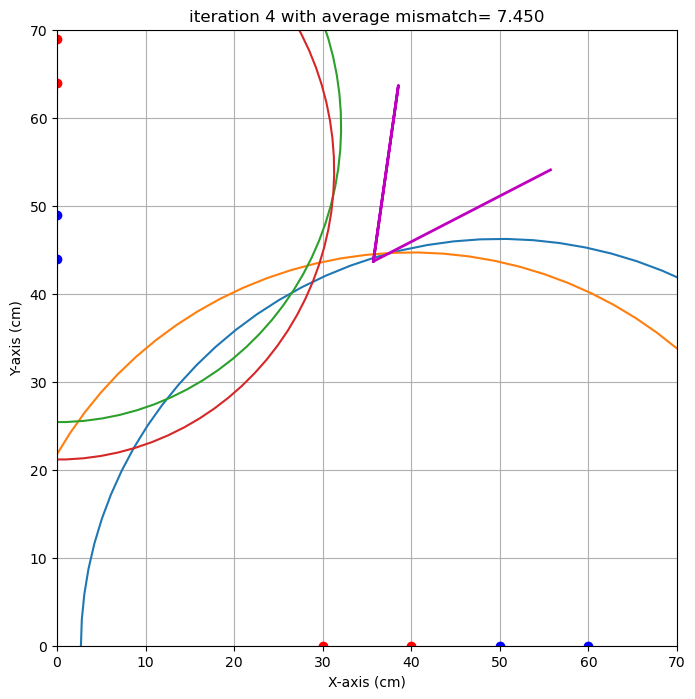

end iteration 4 with average mismatch= 7.450


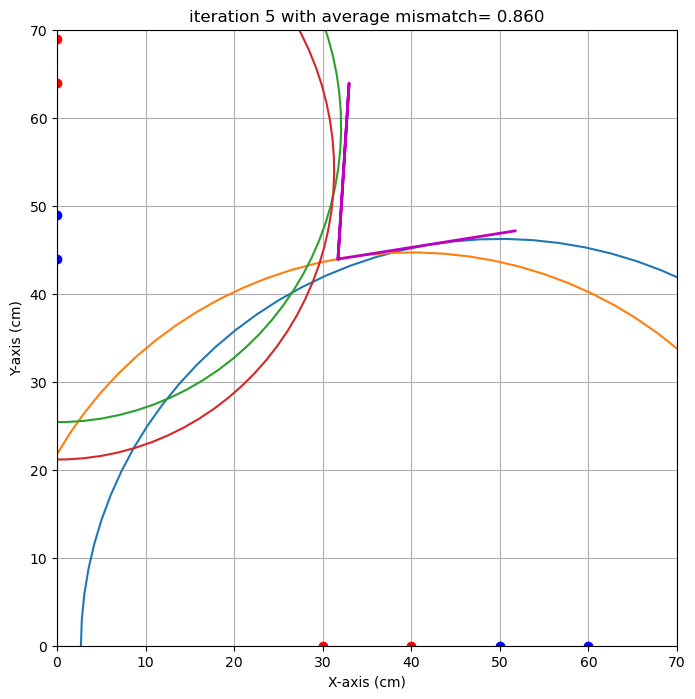

end iteration 5 with average mismatch= 0.860


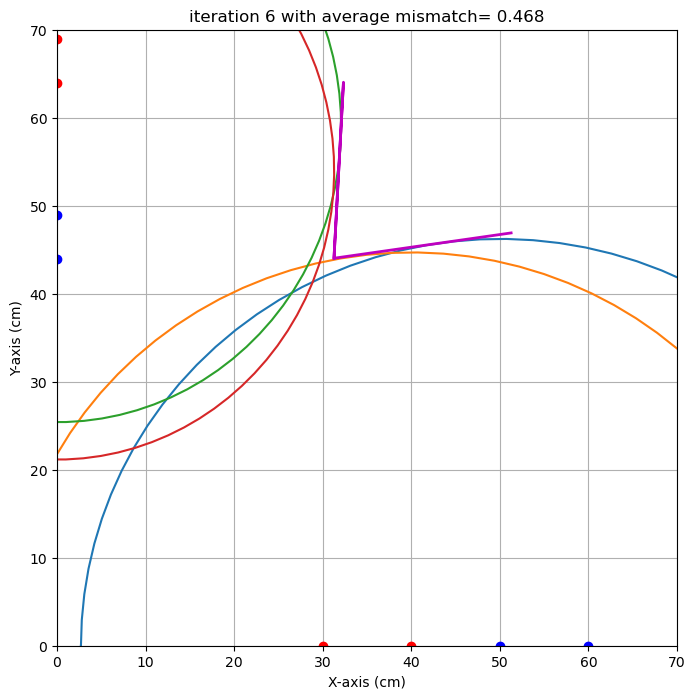

end iteration 6 with average mismatch= 0.468
end iteration 7 with average mismatch= 0.453
end iteration 8 with average mismatch= 0.453
end iteration 9 with average mismatch= 0.453


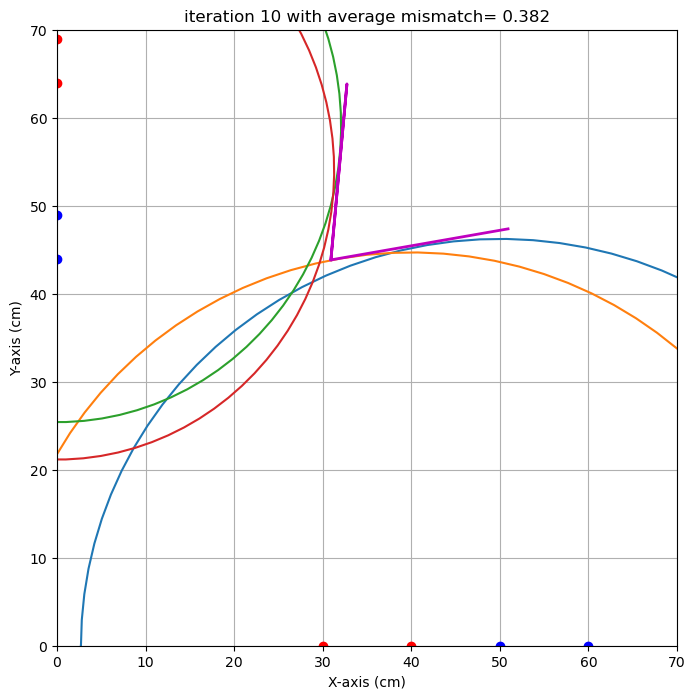

end iteration 10 with average mismatch= 0.382


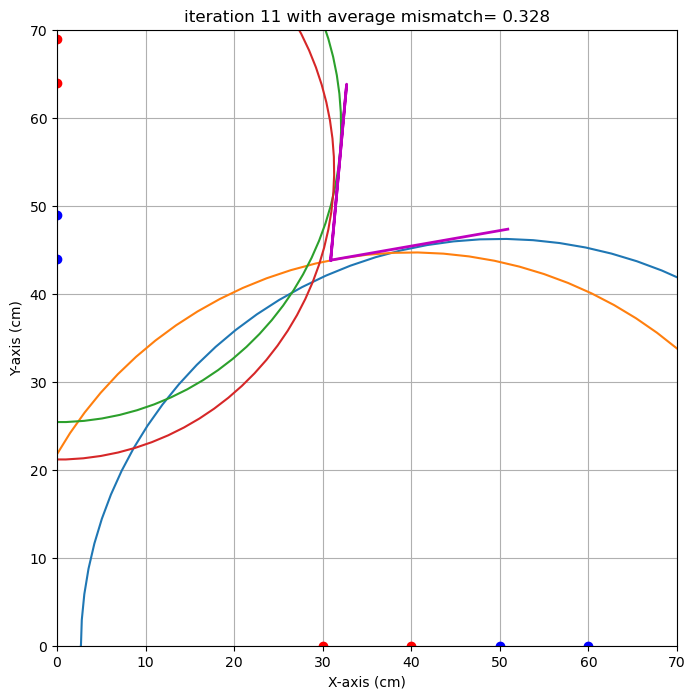

end iteration 11 with average mismatch= 0.328
end iteration 12 with average mismatch= 0.319
end iteration 13 with average mismatch= 0.316
end iteration 14 with average mismatch= 0.315
end iteration 15 with average mismatch= 0.315
end iteration 16 with average mismatch= 0.315
end iteration 17 with average mismatch= 0.315


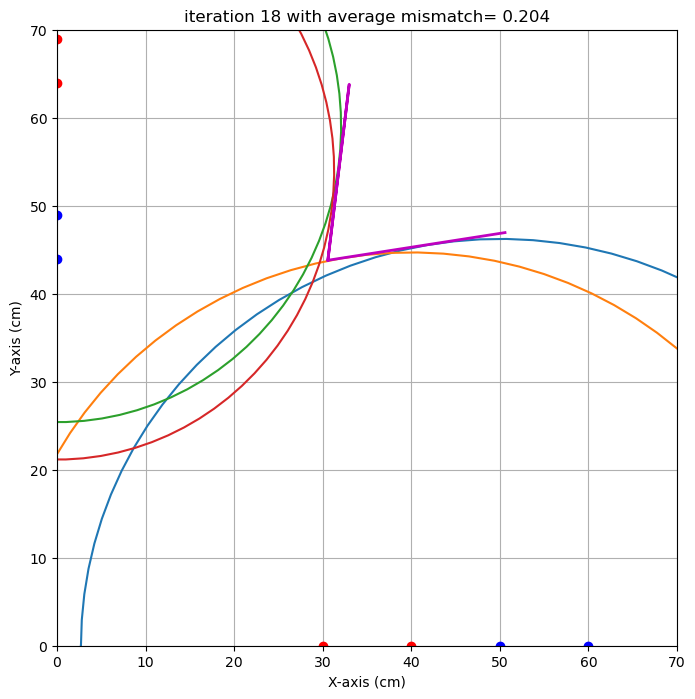

end iteration 18 with average mismatch= 0.204


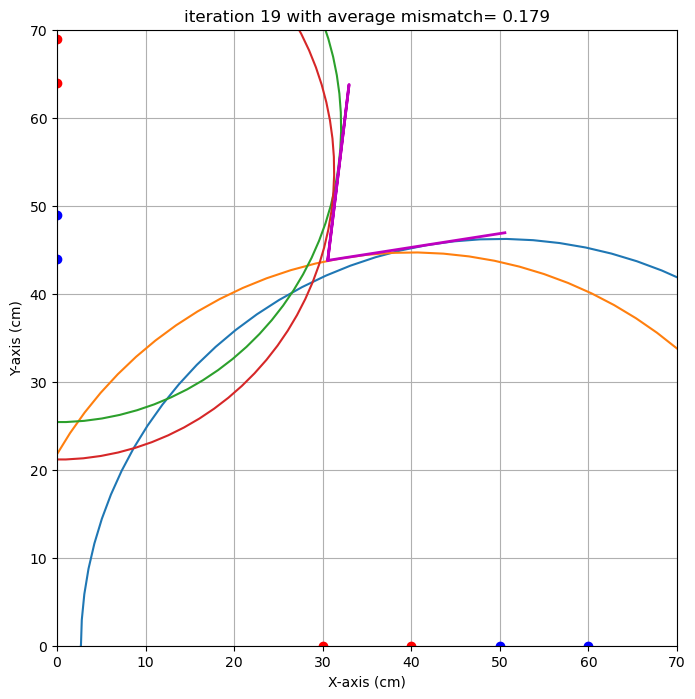

end iteration 19 with average mismatch= 0.179
end iteration 20 with average mismatch= 0.177
end iteration 21 with average mismatch= 0.176
end iteration 22 with average mismatch= 0.176
end iteration 23 with average mismatch= 0.176
end iteration 24 with average mismatch= 0.176
end iteration 25 with average mismatch= 0.176
end iteration 26 with average mismatch= 0.176
end iteration 27 with average mismatch= 0.176
end iteration 28 with average mismatch= 0.176
end iteration 29 with average mismatch= 0.176
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.176
###############################################################################
end of iteration  30
Best alpha=   8.93 with uncertainty=   1.73
Best beta =   6.87 with uncertainty=   3.33
Best x0   =  30.56 with uncertainty=   0.67
Best y0   =  43.78 with uncertainty=   0.15
##############################################################

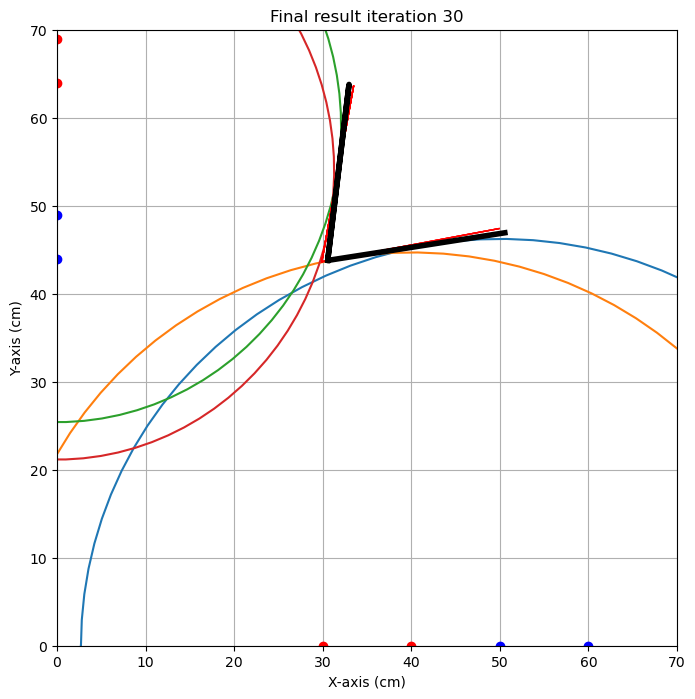

{'alpha': np.float64(8.926952729076062), 'alpha_eps': np.float64(1.7314239004251366), 'beta': np.float64(6.866008717215398), 'beta_eps': np.float64(3.3337049795895846), 'x0': np.float64(30.559855940768532), 'x0_eps': np.float64(0.6680713472694784), 'y0': np.float64(43.78338946789745), 'y0_eps': np.float64(0.1473819153307261)}
locatie 1 
x0 target is : 26.2. Gevonden waarde: 26.7 cm met een standaardafwijking van 0.4 cm 
y0 target is : 37.0. Gevonden waarde: 37.4 cm met een standaardafwijking van 0.6 cm 
alpha target is : 4.3. Gevonden waarde: 5.7 graden met een standaardafwijking van 1.8 graad 
beta target is : -12.9. Gevonden waarde: -11.5 graden met een standaardafwijking van 1.2 graad 

locatie 2 
x0 target is : 29.0. Gevonden waarde: 30.6 cm met een standaardafwijking van 0.7 cm 
y0 target is : 43.0. Gevonden waarde: 43.8 cm met een standaardafwijking van 0.1 cm 
alpha target is : 11.5. Gevonden waarde: 8.9 graden met een standaardafwijking van 1.7 graad 
beta target is : 8.5. Gevo

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':26.2,  #zelf aanvullen,
           'y0':37.0,#zelf aanvullen,
           'alpha' : 4.3,#zelf aanvullen,
           'beta' :-12.9, #zelf aanvullen},
          },
           'locatie 2':{'x0':29,#zelf aanvullen,
                    'y0':43,#zelf aanvullen,
                    'alpha' : 11.5, #zelf aanvullen,
                    'beta' :8.5, #zelf aanvullen}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[    
    [0,60,0,50,47.0], 
    [0,50,0,40,50.2],
    [0,40,0,30,54.1],
    #[0,30,0,20,ongeldig],
    #[20,0,30,0,ongeldig],
    [30,0,40,0,76.7],
    [40,0,50,0,78.3],
    [50,0,60,0,81.1],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[    
    [40,0,60,0,94.6], 
    [30,0,50,0,91.6],
    #[20,0,40,0,ongeldig],
    [0,69,0,49,67.2],
    [0,64,0,44,65.7],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  94.6
1  30   0  50   0  91.6
2   0  69   0  49  67.2
3   0  64   0  44  65.7


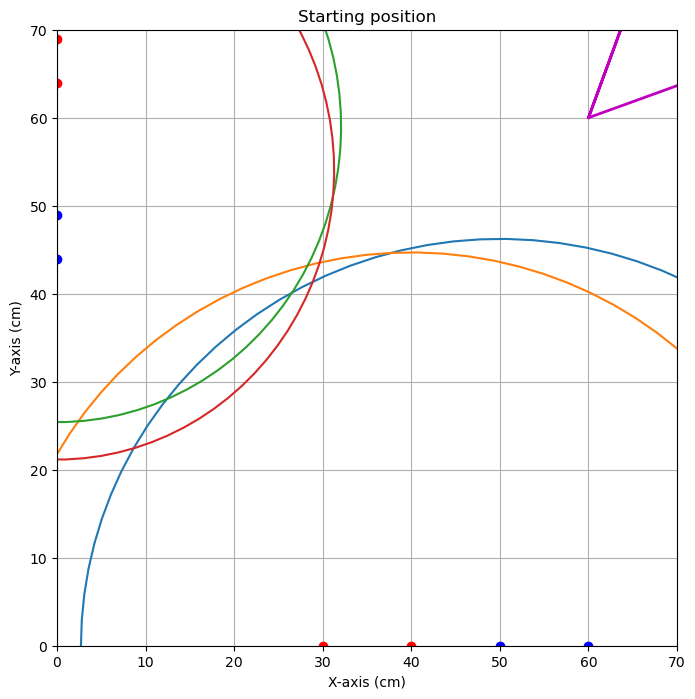


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.577


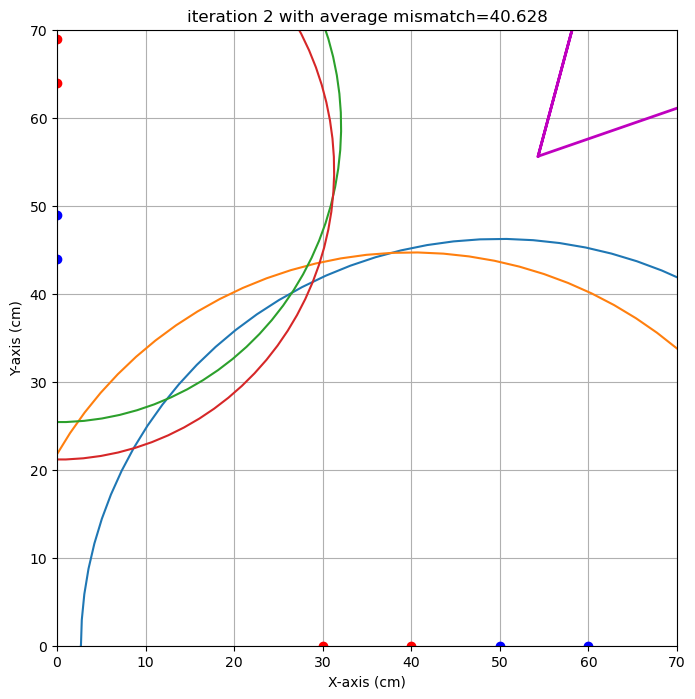

end iteration 2 with average mismatch=40.628


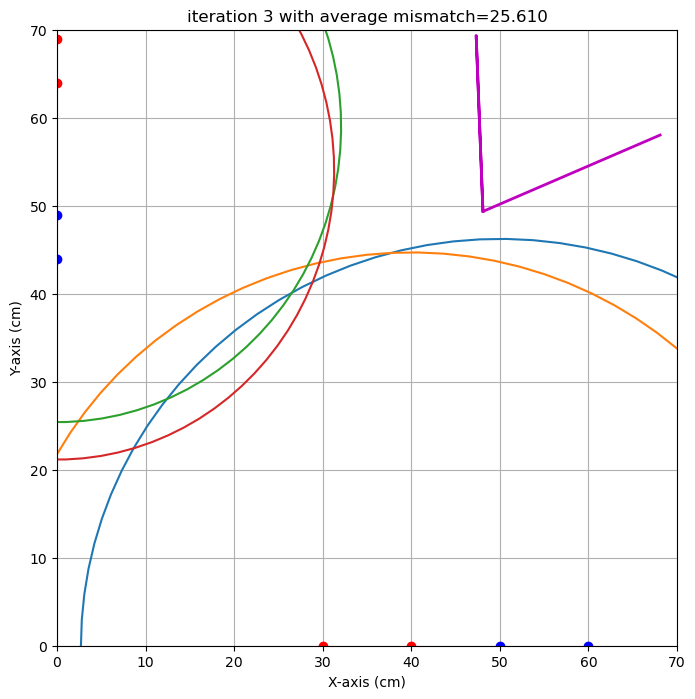

end iteration 3 with average mismatch=25.610


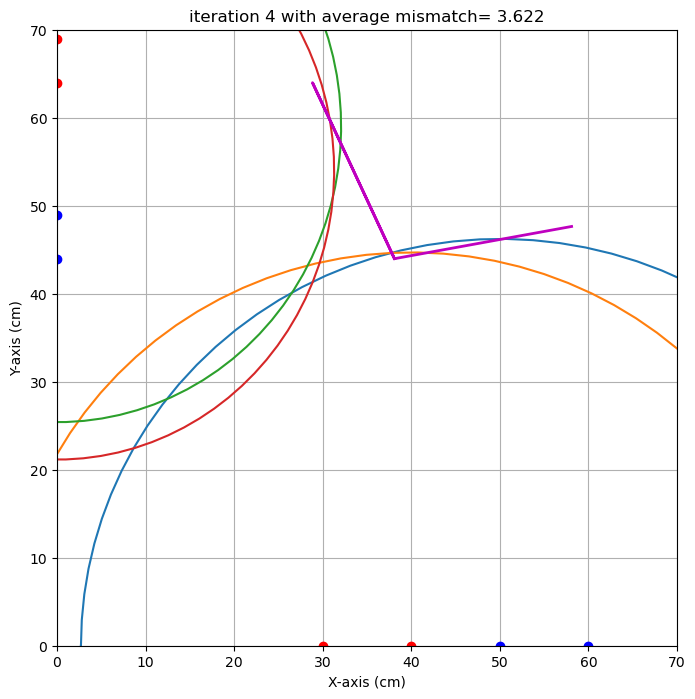

end iteration 4 with average mismatch= 3.622


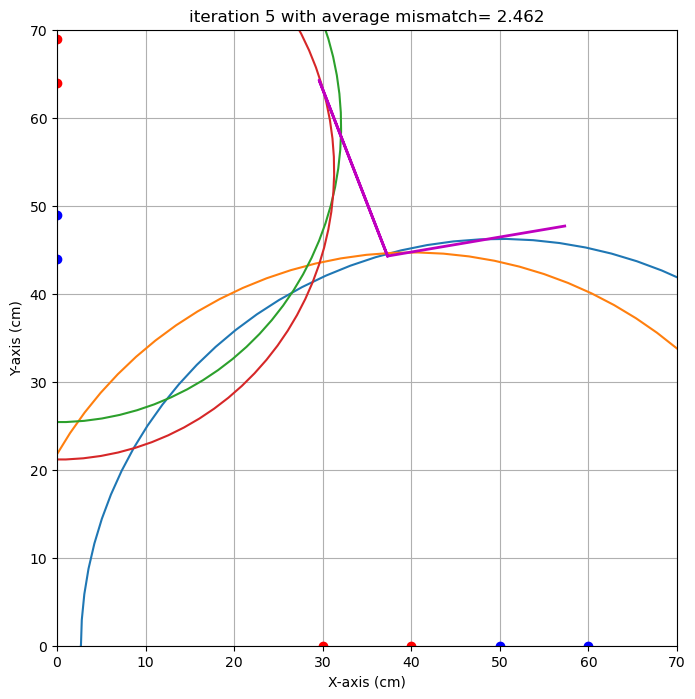

end iteration 5 with average mismatch= 2.462


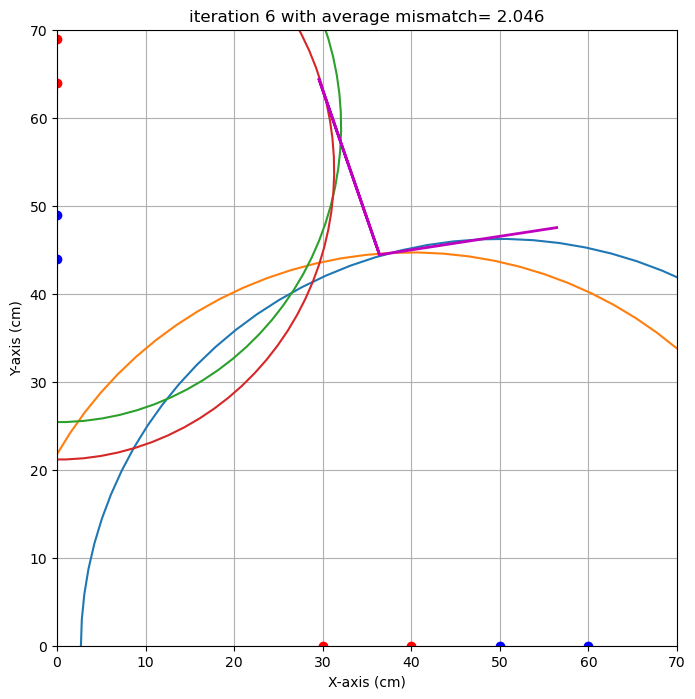

end iteration 6 with average mismatch= 2.046


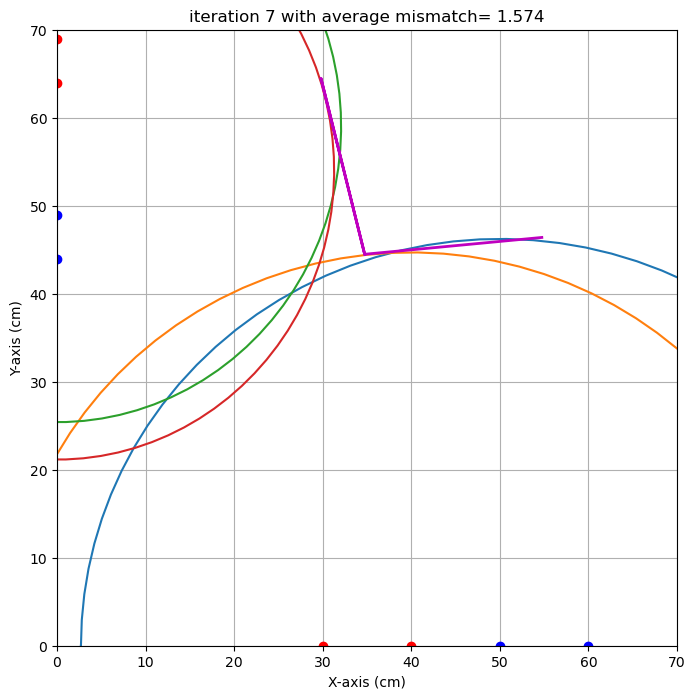

end iteration 7 with average mismatch= 1.574
end iteration 8 with average mismatch= 1.461
end iteration 9 with average mismatch= 1.445
end iteration 10 with average mismatch= 1.374
end iteration 11 with average mismatch= 1.295
end iteration 12 with average mismatch= 1.227
end iteration 13 with average mismatch= 1.227
end iteration 14 with average mismatch= 1.226


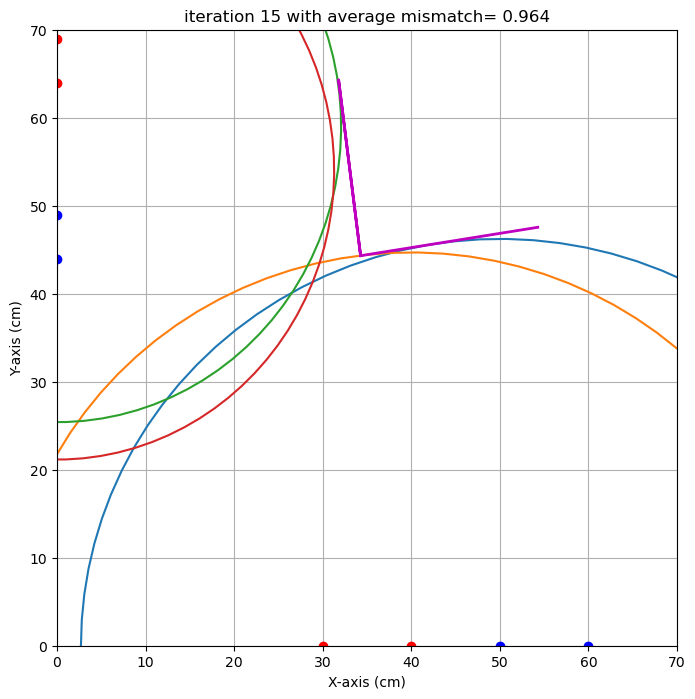

end iteration 15 with average mismatch= 0.964
end iteration 16 with average mismatch= 0.964
end iteration 17 with average mismatch= 0.963
end iteration 18 with average mismatch= 0.963
end iteration 19 with average mismatch= 0.963
end iteration 20 with average mismatch= 0.963
end iteration 21 with average mismatch= 0.963
end iteration 22 with average mismatch= 0.963
end iteration 23 with average mismatch= 0.963


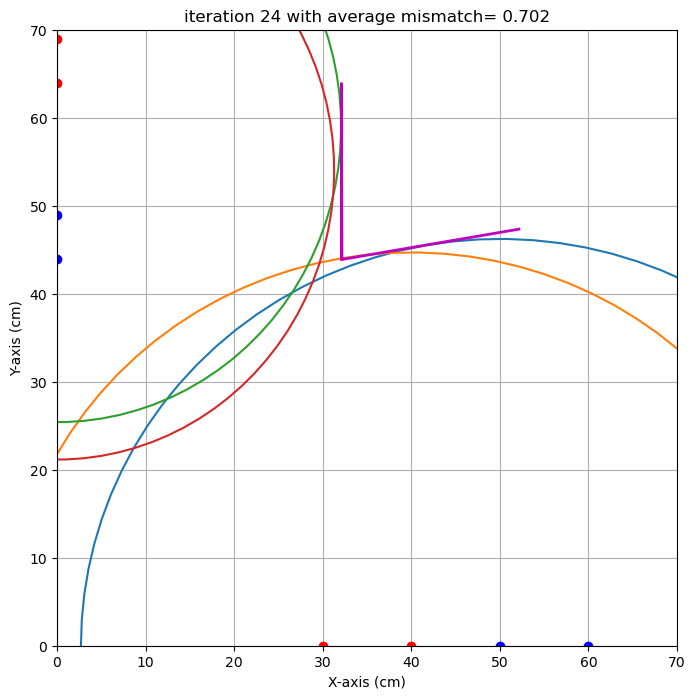

end iteration 24 with average mismatch= 0.702
end iteration 25 with average mismatch= 0.637


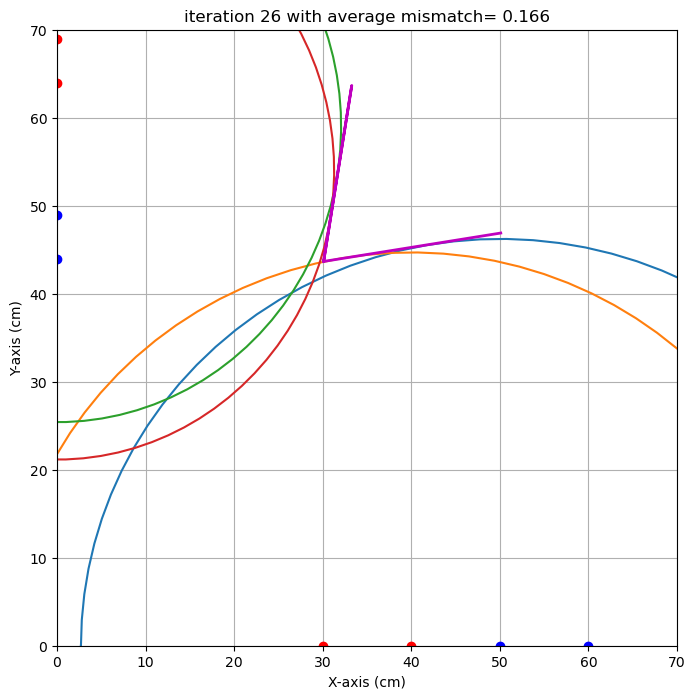

end iteration 26 with average mismatch= 0.166
end iteration 27 with average mismatch= 0.153
end iteration 28 with average mismatch= 0.153
end iteration 29 with average mismatch= 0.153
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.153
###############################################################################
end of iteration  30
Best alpha=   9.17 with uncertainty=   0.81
Best beta =   9.02 with uncertainty=   0.65
Best x0   =  30.08 with uncertainty=   0.33
Best y0   =  43.67 with uncertainty=   0.01
###############################################################################


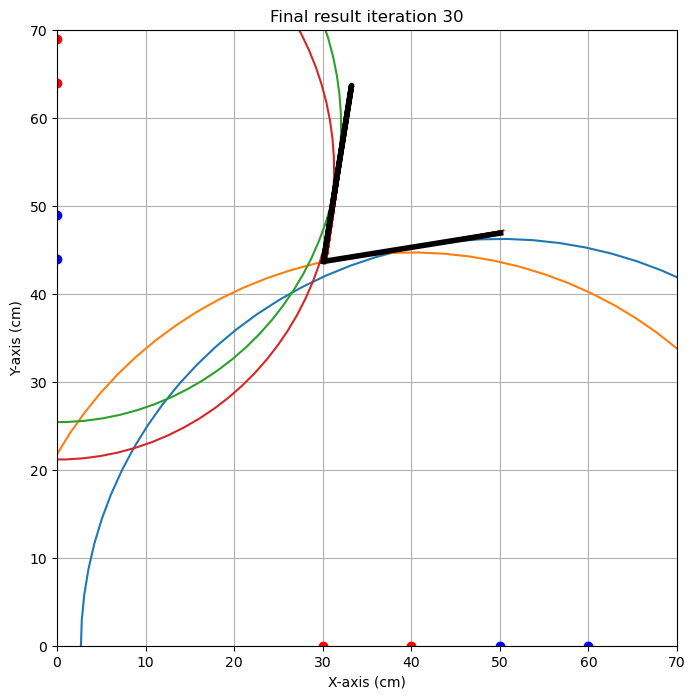

{'alpha': np.float64(9.172031589888276), 'alpha_eps': np.float64(0.8147761381282042), 'beta': np.float64(9.023355999768125), 'beta_eps': np.float64(0.6466070667191328), 'x0': np.float64(30.079221564304863), 'x0_eps': np.float64(0.32965009033375736), 'y0': np.float64(43.667863809263125), 'y0_eps': np.float64(0.0055926554312719645)}
test locatie 
x0 target is : 29.0. Gevonden waarde: 30.1 cm met een standaardafwijking van 0.3 cm 
y0 target is : 43.0. Gevonden waarde: 43.7 cm met een standaardafwijking van 0.0 cm 
alpha target is : 11.5. Gevonden waarde: 9.2 graden met een standaardafwijking van 0.8 graad 
beta target is : 8.5. Gevonden waarde: 9.0 graden met een standaardafwijking van 0.6 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 29, # zelf aanvullen,
                    'y0': 43, # zelf aanvullen,
                    'alpha' : 11.5,  # zelf aanvullen,
                    'beta' : 8.5, # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[ 
    [40,0,60,0,94.6], 
    [30,0,50,0,91.6],
    #[20,0,40,0,ongeldig],
    [0,69,0,49,67.2],
    [0,64,0,44,65.7],
                    
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](hidde2.jpeg "Title")

Figuur: ![Alt](hidde4.jpeg "Title")
We hebben deze aangepast zodat de metingen binnen de bereik en het domein staan, hiermee voorkomen we ongeldige metingen omdat de sensoren binnen de relevante domein/bereik blijven

Figuur: ![Alt](hidde5.jpeg "Title") (iteratie 3)
Nieuwe blokschema gemaakt als nieuwe iteratie om minder metingen te maken en ook minder ongeldige metingen te hebben.